# Phishing URL Detection

The Internet has become an indispensable part of
our life, However, It also has provided opportunities to anonymously perform malicious activities like Phishing. Phishers try to deceive their victims by social engineering or creating mockup websites to steal information such as account ID, username, password from individuals and organizations. Although many methods have been proposed to detect phishing websites, Phishers have evolved their methods to escape from these detection methods. One of the most successful methods for detecting these malicious activities is Machine Learning. This is because most Phishing attacks have some common characteristics which can be identified by machine learning methods.

The steps are as follows:

1. Loading the data
2. Familiarizing with data & EDA
3. Visualizing the data
4. Splitting the data
5. Training the data
6. Comparision of Model
7. Conclusion

In [1]:
#importing required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

## 1. Loading Data:

The dataset is borrowed from Kaggle, https://www.kaggle.com/eswarchandt/phishing-website-detector .

A collection of website URLs for 11000+ websites. Each sample has 32 website parameters and a class label identifying it as a phishing website or not (1 or -1).

In [2]:
#Loading data into dataframe

data = pd.read_csv("Phishing.csv")
data.head()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


In [3]:
# Check current class labels
print("Current class labels:")
print(data['class'].unique())
print(data['class'].value_counts())

# Convert -1 to 0 if necessary
if -1 in data['class'].values:
    print("\n⚠️ Converting class labels from {-1, 1} to {0, 1}...")
    data['class'] = data['class'].replace(-1, 0)
    print("✓ Conversion complete!")
    print("\nNew class labels:")
    print(data['class'].unique())
    print(data['class'].value_counts())

Current class labels:
[-1  1]
class
 1    6157
-1    4897
Name: count, dtype: int64

⚠️ Converting class labels from {-1, 1} to {0, 1}...
✓ Conversion complete!

New class labels:
[0 1]
class
1    6157
0    4897
Name: count, dtype: int64


In [4]:
# Standardize class labels to 0 and 1
if data['class'].min() == -1:
    print("Converting class labels from {-1, 1} to {0, 1}...")
    data['class'] = data['class'].replace({-1: 0, 1: 1})
    print("✓ Labels converted!")

## 2. Familiarizing with Data & EDA:
In this step, few dataframe methods are used to look into the data and its features.

In [5]:
#Shape of dataframe

data.shape

(11054, 32)

In [6]:
#Listing the features of the dataset

data.columns

Index(['Index', 'UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//',
       'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon',
       'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL',
       'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL',
       'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick',
       'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording',
       'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage',
       'StatsReport', 'class'],
      dtype='object')

In [7]:
#Information about the dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3   ShortURL             11054 non-null  int64
 4   Symbol@              11054 non-null  int64
 5   Redirecting//        11054 non-null  int64
 6   PrefixSuffix-        11054 non-null  int64
 7   SubDomains           11054 non-null  int64
 8   HTTPS                11054 non-null  int64
 9   DomainRegLen         11054 non-null  int64
 10  Favicon              11054 non-null  int64
 11  NonStdPort           11054 non-null  int64
 12  HTTPSDomainURL       11054 non-null  int64
 13  RequestURL           11054 non-null  int64
 14  AnchorURL            11054 non-null  int64
 15  LinksInScriptTags    11054 non-null  int64
 16  ServerFormHandler    1

In [8]:
# nunique value in columns

data.nunique()

Index                  11054
UsingIP                    2
LongURL                    3
ShortURL                   2
Symbol@                    2
Redirecting//              2
PrefixSuffix-              2
SubDomains                 3
HTTPS                      3
DomainRegLen               2
Favicon                    2
NonStdPort                 2
HTTPSDomainURL             2
RequestURL                 2
AnchorURL                  3
LinksInScriptTags          3
ServerFormHandler          3
InfoEmail                  2
AbnormalURL                2
WebsiteForwarding          2
StatusBarCust              2
DisableRightClick          2
UsingPopupWindow           2
IframeRedirection          2
AgeofDomain                2
DNSRecording               2
WebsiteTraffic             3
PageRank                   2
GoogleIndex                2
LinksPointingToPage        3
StatsReport                2
class                      2
dtype: int64

In [9]:
#dropping index column

data = data.drop(['Index'],axis = 1)

In [10]:
#description of dataset

data.describe().T

,count,mean,std,min,25%,50%,75%,max
UsingIP,11054.0,0.313914,0.949495,-1.0,-1.0,1.0,1.0,1.0
LongURL,11054.0,-0.633345,0.765973,-1.0,-1.0,-1.0,-1.0,1.0
ShortURL,11054.0,0.738737,0.674024,-1.0,1.0,1.0,1.0,1.0
Symbol@,11054.0,0.700561,0.713625,-1.0,1.0,1.0,1.0,1.0
Redirecting//,11054.0,0.741632,0.670837,-1.0,1.0,1.0,1.0,1.0
PrefixSuffix-,11054.0,-0.734938,0.678165,-1.0,-1.0,-1.0,-1.0,1.0
SubDomains,11054.0,0.064049,0.817492,-1.0,-1.0,0.0,1.0,1.0
HTTPS,11054.0,0.251040,0.911856,-1.0,-1.0,1.0,1.0,1.0
DomainRegLen,11054.0,-0.336711,0.941651,-1.0,-1.0,-1.0,1.0,1.0
Favicon,11054.0,0.628551,0.777804,-1.0,1.0,1.0,1.0,1.0


data_set.append(9 OBSERVATIONS):
1. There are 11054 instances and 31 features in dataset.
2. Out of which 30 are independent features where as 1 is dependent feature.
3. Each feature is in int datatype, so there is no need to use LabelEncoder.
4. There is no outlier present in dataset.
5. There are no missing value in dataset.

## 3. Visualizing the data:
Few plots and graphs are displayed to find how the data is distributed and the how features are related to each other.

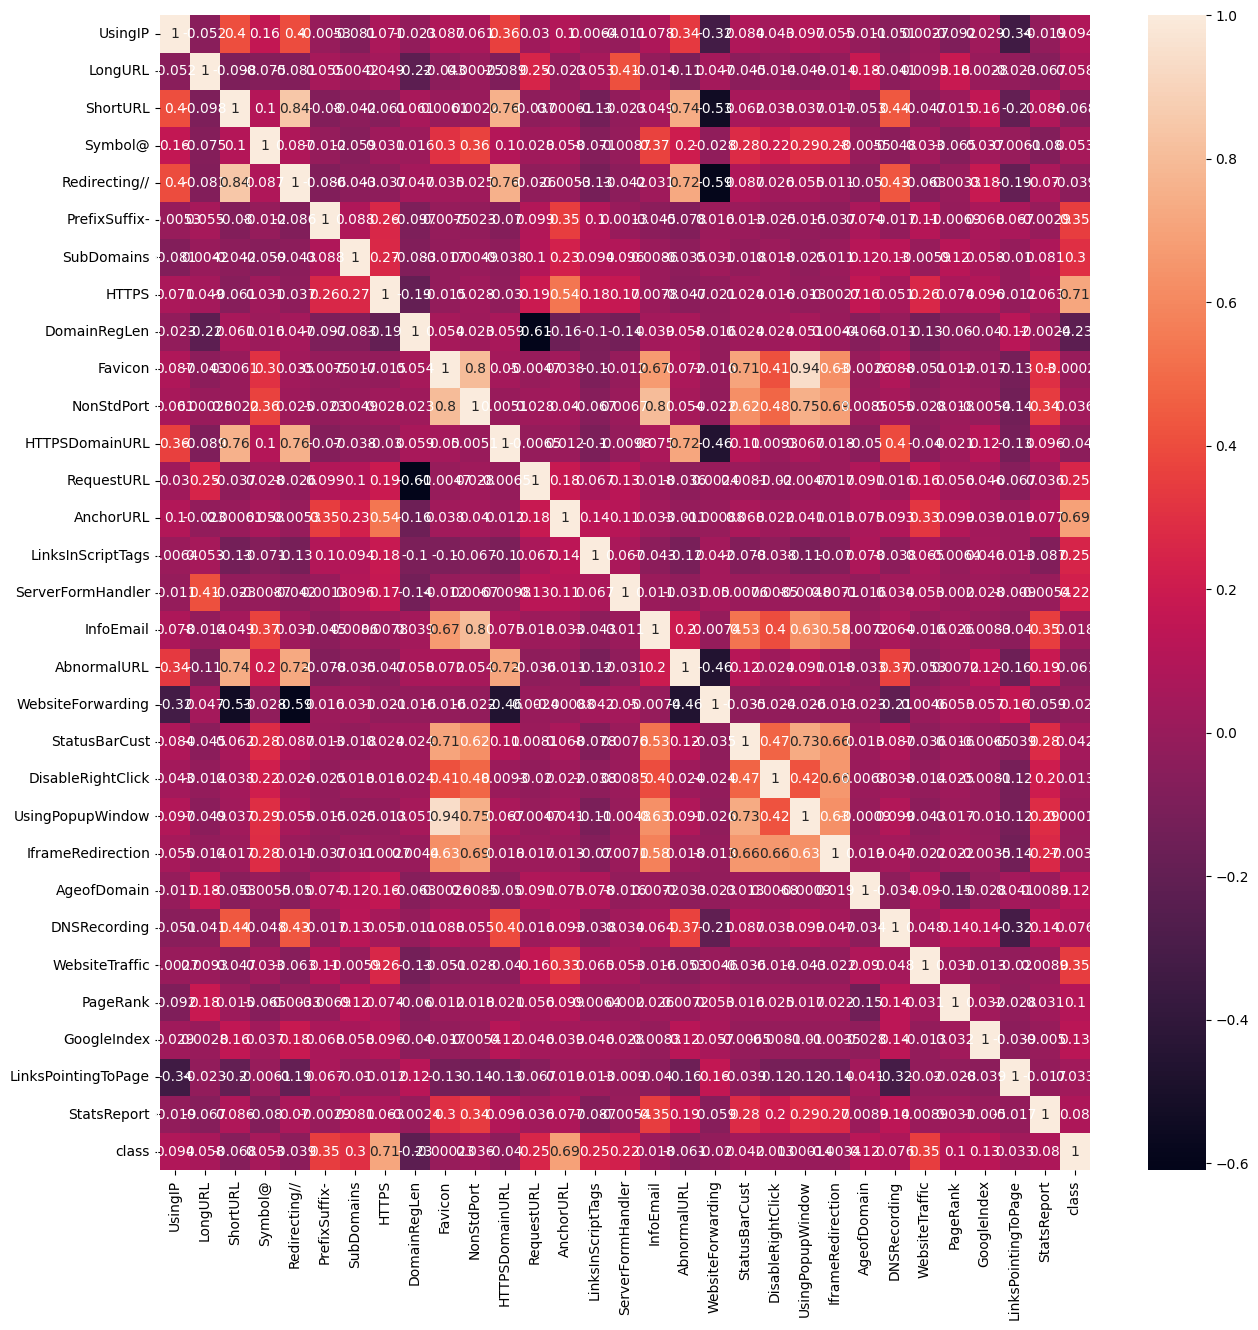

In [11]:
#Correlation heatmap

plt.figure(figsize=(15,15))
sns.heatmap(data.corr(), annot=True)
plt.show()

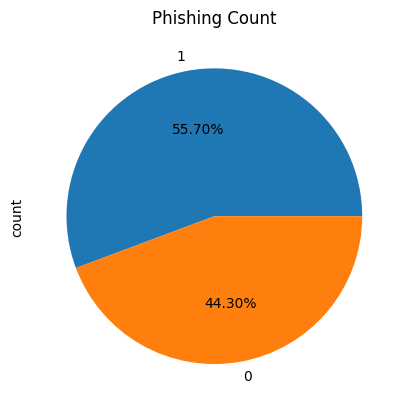

In [12]:
# Phishing Count in pie chart

data['class'].value_counts().plot(kind='pie',autopct='%1.2f%%')
plt.title("Phishing Count")
plt.show()

## 4. Splitting the Data:
The data is split into train & test sets, 80-20 split.

In [13]:
# Splitting the dataset into dependant and independant fetature

X = data.drop(["class"],axis =1)
y = data["class"]

In [14]:
# Splitting the dataset into train and test sets: 80-20 split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8843, 30), (8843,), (2211, 30), (2211,))

## 5. Model Building & Training:
   Supervised machine learning is one of the most commonly used and successful types of machine learning. Supervised learning is used whenever we want to predict a certain outcome/label from a given set of features, and we have examples of features-label pairs. We build a machine learning model from these features-label pairs, which comprise our training set. Our goal is to make accurate predictions for new, never-before-seen data.

   There are two major types of supervised machine learning problems, called classification and regression. Our data set comes under regression problem, as the prediction of suicide rate is a continuous number, or a floating-point number in programming terms. The supervised machine learning models (regression) considered to train the dataset in this notebook are:

1. Logistic Regression
2. k-Nearest Neighbors
3. Support Vector Clasifier
4. Naive Bayes
5. Decision Tree
6. Random Forest
7. Gradient Boosting
8. Catboost
9. Multilayer Perceptrons

              
  The metrics considered to evaluate the model performance are Accuracy , Precison , Recall , F1 score and AUC curve.

In [15]:
# Creating holders to store the model performance results
ML_Model = []
accuracy = []
f1_score = []
recall = []
precision = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
  ML_Model.append(model)
  accuracy.append(round(a, 3))
  f1_score.append(round(b, 3))
  recall.append(round(c, 3))
  precision.append(round(d, 3))

## 5.1. Logistic Regression

Logistic regression predicts the output of a categorical dependent variable. Therefore the outcome must be a categorical or discrete value. Logistic Regression is much similar to the Linear Regression except that how they are used. Linear Regression is used for solving Regression problems, whereas Logistic regression is used for solving the classification problems.

In [16]:
# Check class distribution
print("Class Distribution:")
print(data['class'].value_counts())
print("\nClass Distribution (%):")
print(data['class'].value_counts(normalize=True) * 100)

Class Distribution:
class
1    6157
0    4897
Name: count, dtype: int64

Class Distribution (%):
class
1    55.699294
0    44.300706
Name: proportion, dtype: float64


In [17]:
# Display all feature columns
print("Features in dataset:")
print(data.columns.tolist())
print(f"\nTotal features: {len(data.columns) - 1}")  # -1 for class column

Features in dataset:
['UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport', 'class']

Total features: 30


In [18]:
# Feature Scaling - IMPORTANT for Logistic Regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


In [19]:
# # Linear regression model
# from sklearn.linear_model import LogisticRegression
# #from sklearn.pipeline import Pipeline

# # instantiate the model
# log = LogisticRegression()

# # fit the model
# log.fit(X_train,y_train)

# Logistic Regression model with scaling
from sklearn.linear_model import LogisticRegression

# instantiate the model with more iterations
log = LogisticRegression(max_iter=1000, random_state=42)

# fit the model with SCALED data
log.fit(X_train_scaled, y_train)

# predicting the target value from the model for the samples
y_train_log = log.predict(X_train_scaled)
y_test_log = log.predict(X_test_scaled)

In [20]:
#predicting the target value from the model for the samples

y_train_log = log.predict(X_train)
y_test_log = log.predict(X_test)

In [21]:
#computing the accuracy, f1_score, Recall, precision of the model performance

acc_train_log = metrics.accuracy_score(y_train,y_train_log)
acc_test_log = metrics.accuracy_score(y_test,y_test_log)
print("Logistic Regression : Accuracy on training Data: {:.3f}".format(acc_train_log))
print("Logistic Regression : Accuracy on test Data: {:.3f}".format(acc_test_log))
print()

f1_score_train_log = metrics.f1_score(y_train,y_train_log)
f1_score_test_log = metrics.f1_score(y_test,y_test_log)
print("Logistic Regression : f1_score on training Data: {:.3f}".format(f1_score_train_log))
print("Logistic Regression : f1_score on test Data: {:.3f}".format(f1_score_test_log))
print()

recall_score_train_log = metrics.recall_score(y_train,y_train_log)
recall_score_test_log = metrics.recall_score(y_test,y_test_log)
print("Logistic Regression : Recall on training Data: {:.3f}".format(recall_score_train_log))
print("Logistic Regression : Recall on test Data: {:.3f}".format(recall_score_test_log))
print()

precision_score_train_log = metrics.precision_score(y_train,y_train_log)
precision_score_test_log = metrics.precision_score(y_test,y_test_log)
print("Logistic Regression : precision on training Data: {:.3f}".format(precision_score_train_log))
print("Logistic Regression : precision on test Data: {:.3f}".format(precision_score_test_log))

Logistic Regression : Accuracy on training Data: 0.917
Logistic Regression : Accuracy on test Data: 0.914

Logistic Regression : f1_score on training Data: 0.923
Logistic Regression : f1_score on test Data: 0.920

Logistic Regression : Recall on training Data: 0.892
Logistic Regression : Recall on test Data: 0.888

Logistic Regression : precision on training Data: 0.956
Logistic Regression : precision on test Data: 0.954


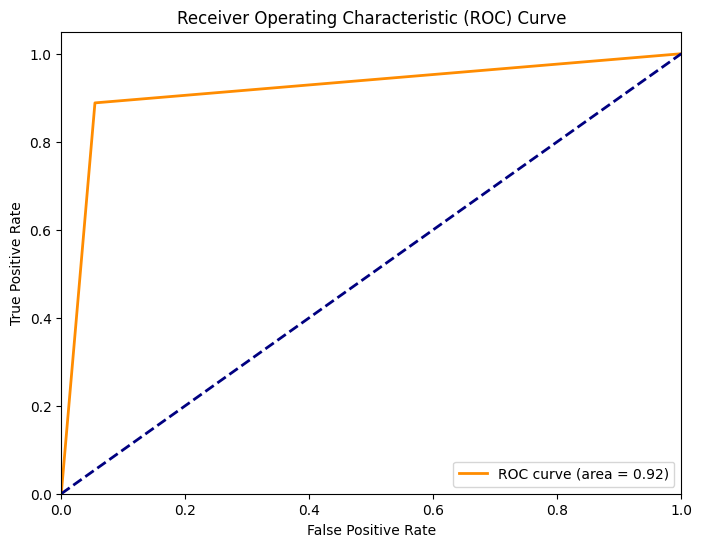

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and ROC area for each class
fpr, tpr, _ = roc_curve(y_test, y_test_log)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [23]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_log))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91       976
           1       0.95      0.89      0.92      1235

    accuracy                           0.91      2211
   macro avg       0.91      0.92      0.91      2211
weighted avg       0.92      0.91      0.91      2211



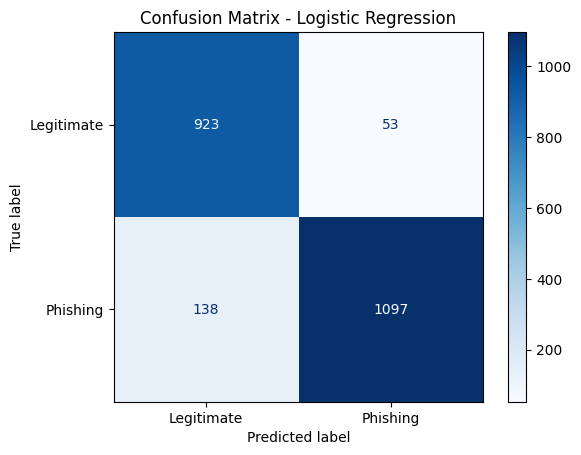


False Positives (Legitimate marked as Phishing): 53
False Negatives (Phishing marked as Legitimate): 138
True Negatives (Legitimate correctly identified): 923
True Positives (Phishing correctly identified): 1097


In [24]:
# Confusion Matrix - CRITICAL for understanding false positives
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

print(f"\nFalse Positives (Legitimate marked as Phishing): {cm[0][1]}")
print(f"False Negatives (Phishing marked as Legitimate): {cm[1][0]}")
print(f"True Negatives (Legitimate correctly identified): {cm[0][0]}")
print(f"True Positives (Phishing correctly identified): {cm[1][1]}")

In [25]:
# #storing the results. The below mentioned order of parameter passing is important.

# storeResults('Logistic Regression',acc_test_log,f1_score_test_log,
#              recall_score_train_log,precision_score_train_log)

storeResults('Logistic Regression', acc_test_log, f1_score_test_log,
             recall_score_test_log, precision_score_test_log)

## 5.2. K-Nearest Neighbors : Classifier

K-Nearest Neighbour is one of the simplest Machine Learning algorithms based on Supervised Learning technique. K-NN algorithm assumes the similarity between the new case/data and available cases and put the new case into the category that is most similar to the available categories.

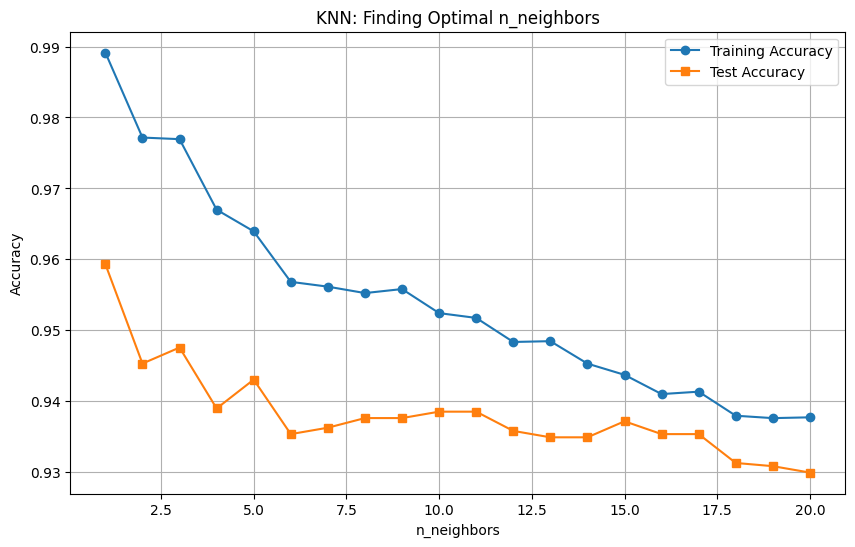


Optimal n_neighbors: 1
Best test accuracy: 0.959


In [26]:
# # K-Nearest Neighbors Classifier model
# from sklearn.neighbors import KNeighborsClassifier

# # instantiate the model
# knn = KNeighborsClassifier(n_neighbors=1)

# # fit the model
# knn.fit(X_train,y_train)

# K-Nearest Neighbors Classifier model with SCALING and OPTIMIZED n_neighbors
from sklearn.neighbors import KNeighborsClassifier

# Find optimal n_neighbors first
training_accuracy = []
test_accuracy = []
neighbors_range = range(1, 21)

for n in neighbors_range:
    knn_temp = KNeighborsClassifier(n_neighbors=n)
    knn_temp.fit(X_train_scaled, y_train)  # Use SCALED data
    training_accuracy.append(knn_temp.score(X_train_scaled, y_train))
    test_accuracy.append(knn_temp.score(X_test_scaled, y_test))

# Plot to find optimal k
plt.figure(figsize=(10, 6))
plt.plot(neighbors_range, training_accuracy, label="Training Accuracy", marker='o')
plt.plot(neighbors_range, test_accuracy, label="Test Accuracy", marker='s')
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.title("KNN: Finding Optimal n_neighbors")
plt.legend()
plt.grid(True)
plt.show()

# Find best n_neighbors
optimal_k = neighbors_range[test_accuracy.index(max(test_accuracy))]
print(f"\nOptimal n_neighbors: {optimal_k}")
print(f"Best test accuracy: {max(test_accuracy):.3f}")

In [27]:
# Train final model with optimal k
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train_scaled, y_train)  # Use SCALED data

# Predict
y_train_knn = knn.predict(X_train_scaled)
y_test_knn = knn.predict(X_test_scaled)

In [28]:
# Computing metrics
acc_train_knn = metrics.accuracy_score(y_train, y_train_knn)
acc_test_knn = metrics.accuracy_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Accuracy on training Data: {:.3f}".format(acc_train_knn))
print("K-Nearest Neighbors : Accuracy on test Data: {:.3f}".format(acc_test_knn))
print()

f1_score_train_knn = metrics.f1_score(y_train, y_train_knn)
f1_score_test_knn = metrics.f1_score(y_test, y_test_knn)
print("K-Nearest Neighbors : f1_score on training Data: {:.3f}".format(f1_score_train_knn))
print("K-Nearest Neighbors : f1_score on test Data: {:.3f}".format(f1_score_test_knn))
print()

recall_score_train_knn = metrics.recall_score(y_train, y_train_knn)
recall_score_test_knn = metrics.recall_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Recall on training Data: {:.3f}".format(recall_score_train_knn))
print("K-Nearest Neighbors : Recall on test Data: {:.3f}".format(recall_score_test_knn))
print()

precision_score_train_knn = metrics.precision_score(y_train, y_train_knn)
precision_score_test_knn = metrics.precision_score(y_test, y_test_knn)
print("K-Nearest Neighbors : precision on training Data: {:.3f}".format(precision_score_train_knn))
print("K-Nearest Neighbors : precision on test Data: {:.3f}".format(precision_score_test_knn))

K-Nearest Neighbors : Accuracy on training Data: 0.989
K-Nearest Neighbors : Accuracy on test Data: 0.959

K-Nearest Neighbors : f1_score on training Data: 0.990
K-Nearest Neighbors : f1_score on test Data: 0.964

K-Nearest Neighbors : Recall on training Data: 0.991
K-Nearest Neighbors : Recall on test Data: 0.964

K-Nearest Neighbors : precision on training Data: 0.989
K-Nearest Neighbors : precision on test Data: 0.964


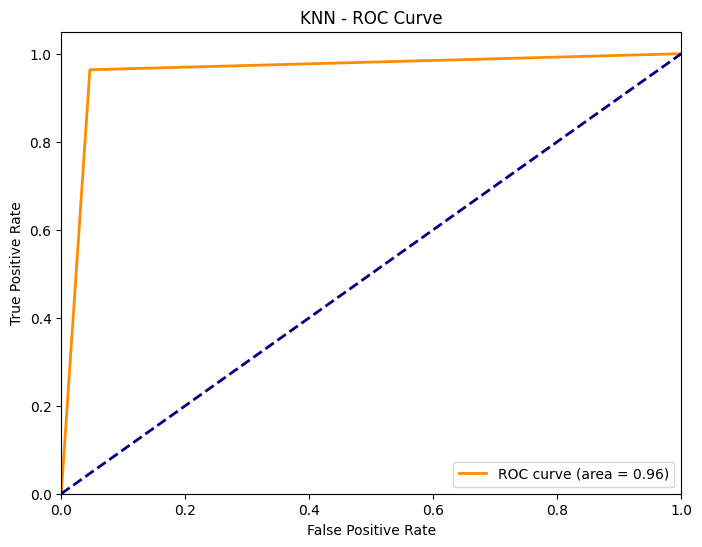

In [29]:
# ROC Curve
from sklearn.metrics import roc_curve, auc

# Get probability predictions for ROC curve
y_test_knn_proba = knn.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_test_knn_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN - ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [30]:
# Classification Report
print(metrics.classification_report(y_test, y_test_knn))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       976
           1       0.96      0.96      0.96      1235

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211



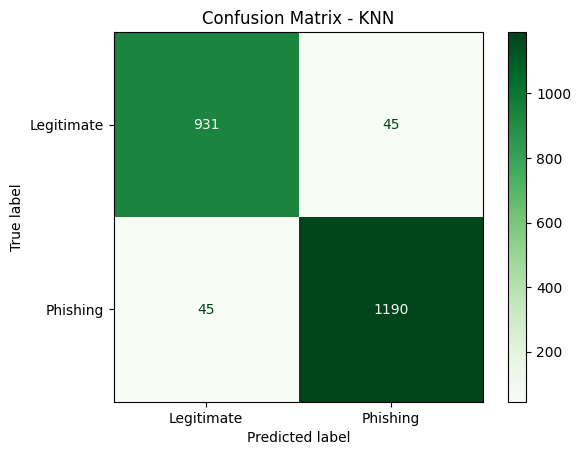


False Positives: 45
False Negatives: 45


In [31]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix - KNN')
plt.show()

print(f"\nFalse Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")

In [32]:
# FIXED: Store TEST metrics (not training)
storeResults('K-Nearest Neighbors', acc_test_knn, f1_score_test_knn,
             recall_score_test_knn, precision_score_test_knn)  # ← FIXED!

## 5.3. Support Vector Machine : Classifier

Support Vector Machine or SVM is one of the most popular Supervised Learning algorithms, which is used for Classification as well as Regression problems. The goal of the SVM algorithm is to create the best line or decision boundary that can segregate n-dimensional space into classes so that we can easily put the new data point in the correct category in the future.

Gamma (gamma):

Gamma is a parameter for non-linear hyperplanes.
The higher the value of gamma, the more influence a single training example has. It defines how far the influence of a single training example reaches.
Low values mean that the influence is 'far', and high values mean that the influence is 'close'. In other words, a low value of gamma will create a broader decision boundary, while a high value will create a more complex decision boundary that fits the training data more closely.
If gamma is too high, the model may overfit the training data, and if it's too low, it may underfit.
Kernel (kernel):

The kernel specifies the type of hyperplane used to separate the data.
Common choices for the kernel are 'linear', 'rbf' (Radial basis function), 'poly' (polynomial), and 'sigmoid'.
The choice of the kernel determines the shape of the decision boundary:
'linear': Linear decision boundary.
'rbf' (Radial basis function): Non-linear decision boundary. It is often a good choice when the data is not linearly separable.
'poly' (Polynomial): Non-linear decision boundary with a polynomial function.
'sigmoid': S-shaped decision boundary.

In [33]:
# Support Vector Classifier model with proper scaling and hyperparameter tuning
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Expanded parameter grid for better tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

print("Starting GridSearchCV for SVM... This may take a few minutes.")
print("Testing combinations:", len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel']))

# Create SVM with GridSearchCV - using SCALED data
svc = GridSearchCV(
    SVC(probability=True, random_state=42),  # probability=True for ROC curve
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='f1',  # Optimize for F1 score
    n_jobs=-1,  # Use all CPU cores
    verbose=1
)

# Fit the model with SCALED data
svc.fit(X_train_scaled, y_train)

# Display best parameters found
print("\nBest parameters found:")
print(svc.best_params_)
print(f"Best cross-validation F1 score: {svc.best_score_:.3f}")

Starting GridSearchCV for SVM... This may take a few minutes.
Testing combinations: 48
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best parameters found:
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation F1 score: 0.969


In [34]:
# Predicting with SCALED data
y_train_svc = svc.predict(X_train_scaled)
y_test_svc = svc.predict(X_test_scaled)

In [35]:
# Computing the accuracy, f1_score, Recall, precision of the model performance
acc_train_svc = metrics.accuracy_score(y_train, y_train_svc)
acc_test_svc = metrics.accuracy_score(y_test, y_test_svc)
print("Support Vector Machine : Accuracy on training Data: {:.3f}".format(acc_train_svc))
print("Support Vector Machine : Accuracy on test Data: {:.3f}".format(acc_test_svc))
print()

f1_score_train_svc = metrics.f1_score(y_train, y_train_svc)
f1_score_test_svc = metrics.f1_score(y_test, y_test_svc)
print("Support Vector Machine : f1_score on training Data: {:.3f}".format(f1_score_train_svc))
print("Support Vector Machine : f1_score on test Data: {:.3f}".format(f1_score_test_svc))
print()

recall_score_train_svc = metrics.recall_score(y_train, y_train_svc)
recall_score_test_svc = metrics.recall_score(y_test, y_test_svc)
print("Support Vector Machine : Recall on training Data: {:.3f}".format(recall_score_train_svc))
print("Support Vector Machine : Recall on test Data: {:.3f}".format(recall_score_test_svc))
print()

precision_score_train_svc = metrics.precision_score(y_train, y_train_svc)
precision_score_test_svc = metrics.precision_score(y_test, y_test_svc)
print("Support Vector Machine : precision on training Data: {:.3f}".format(precision_score_train_svc))
print("Support Vector Machine : precision on test Data: {:.3f}".format(precision_score_test_svc))

Support Vector Machine : Accuracy on training Data: 0.988
Support Vector Machine : Accuracy on test Data: 0.968

Support Vector Machine : f1_score on training Data: 0.990
Support Vector Machine : f1_score on test Data: 0.972

Support Vector Machine : Recall on training Data: 0.994
Support Vector Machine : Recall on test Data: 0.979

Support Vector Machine : precision on training Data: 0.985
Support Vector Machine : precision on test Data: 0.965


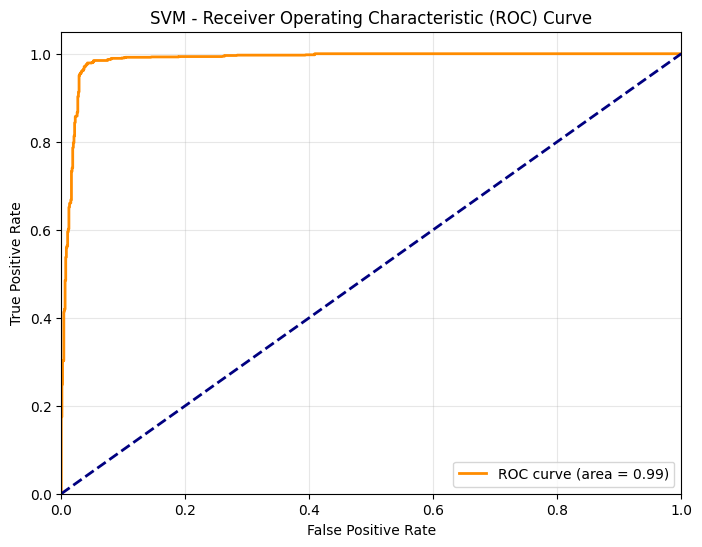

AUC-ROC Score: 0.987


In [36]:
# ROC Curve with probability predictions
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get probability predictions for proper ROC curve
y_test_svc_proba = svc.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_test, y_test_svc_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM - Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"AUC-ROC Score: {roc_auc:.3f}")

In [37]:
# Classification report
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_test_svc))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       976
           1       0.96      0.98      0.97      1235

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



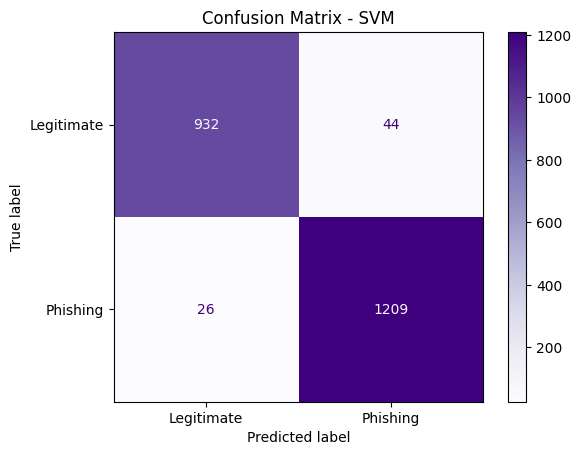


False Positives (Legitimate marked as Phishing): 44
False Negatives (Phishing marked as Legitimate): 26
True Negatives (Legitimate correctly identified): 932
True Positives (Phishing correctly identified): 1209


In [38]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_svc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='Purples')
plt.title('Confusion Matrix - SVM')
plt.show()

print(f"\nFalse Positives (Legitimate marked as Phishing): {cm[0][1]}")
print(f"False Negatives (Phishing marked as Legitimate): {cm[1][0]}")
print(f"True Negatives (Legitimate correctly identified): {cm[0][0]}")
print(f"True Positives (Phishing correctly identified): {cm[1][1]}")

In [39]:
# FIXED: Storing TEST metrics (not training)
storeResults('Support Vector Machine', acc_test_svc, f1_score_test_svc,
             recall_score_test_svc, precision_score_test_svc)  # ← FIXED!

## 5.4. Naive Bayes : Classifier

Naïve Bayes algorithm is a supervised learning algorithm, which is based on Bayes theorem and used for solving classification problems.It is mainly used in text, image classification that includes a high-dimensional training dataset. Naïve Bayes Classifier is one of the simple and most effective Classification algorithms which helps in building the fast machine learning models that can make quick predictions.

In [40]:
# Naive Bayes Classifier Model
from sklearn.naive_bayes import GaussianNB

# Instantiate the model with variance smoothing for numerical stability
nb = GaussianNB(var_smoothing=1e-9)

# Fit the model - Naive Bayes works with both scaled and unscaled data
# But we'll use scaled for consistency
nb.fit(X_train_scaled, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [41]:
# Predicting the target value from the model for the samples
y_train_nb = nb.predict(X_train_scaled)
y_test_nb = nb.predict(X_test_scaled)

In [42]:
# Computing the accuracy, f1_score, Recall, precision of the model performance
acc_train_nb = metrics.accuracy_score(y_train, y_train_nb)
acc_test_nb = metrics.accuracy_score(y_test, y_test_nb)
print("Naive Bayes Classifier : Accuracy on training Data: {:.3f}".format(acc_train_nb))
print("Naive Bayes Classifier : Accuracy on test Data: {:.3f}".format(acc_test_nb))
print()

f1_score_train_nb = metrics.f1_score(y_train, y_train_nb)
f1_score_test_nb = metrics.f1_score(y_test, y_test_nb)
print("Naive Bayes Classifier : f1_score on training Data: {:.3f}".format(f1_score_train_nb))
print("Naive Bayes Classifier : f1_score on test Data: {:.3f}".format(f1_score_test_nb))
print()

recall_score_train_nb = metrics.recall_score(y_train, y_train_nb)
recall_score_test_nb = metrics.recall_score(y_test, y_test_nb)
print("Naive Bayes Classifier : Recall on training Data: {:.3f}".format(recall_score_train_nb))
print("Naive Bayes Classifier : Recall on test Data: {:.3f}".format(recall_score_test_nb))
print()

precision_score_train_nb = metrics.precision_score(y_train, y_train_nb)
precision_score_test_nb = metrics.precision_score(y_test, y_test_nb)
print("Naive Bayes Classifier : precision on training Data: {:.3f}".format(precision_score_train_nb))
print("Naive Bayes Classifier : precision on test Data: {:.3f}".format(precision_score_test_nb))

Naive Bayes Classifier : Accuracy on training Data: 0.599
Naive Bayes Classifier : Accuracy on test Data: 0.599

Naive Bayes Classifier : f1_score on training Data: 0.438
Naive Bayes Classifier : f1_score on test Data: 0.441

Naive Bayes Classifier : Recall on training Data: 0.281
Naive Bayes Classifier : Recall on test Data: 0.283

Naive Bayes Classifier : precision on training Data: 0.996
Naive Bayes Classifier : precision on test Data: 0.994


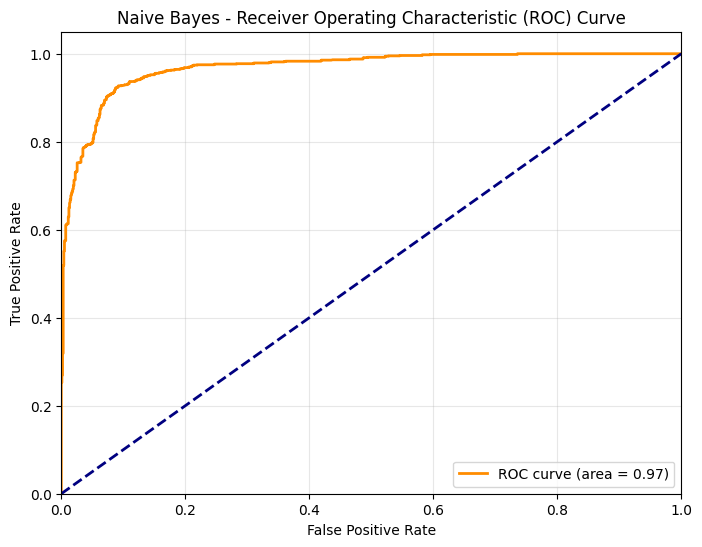

AUC-ROC Score: 0.968


In [43]:
# ROC Curve with probability predictions
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get probability predictions for proper ROC curve
y_test_nb_proba = nb.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_test, y_test_nb_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Naive Bayes - Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"AUC-ROC Score: {roc_auc:.3f}")

In [44]:
# Computing the classification report of the model
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_test_nb))  # ← FIXED: was y_test_svc


Classification Report:
              precision    recall  f1-score   support

           0       0.52      1.00      0.69       976
           1       0.99      0.28      0.44      1235

    accuracy                           0.60      2211
   macro avg       0.76      0.64      0.56      2211
weighted avg       0.79      0.60      0.55      2211



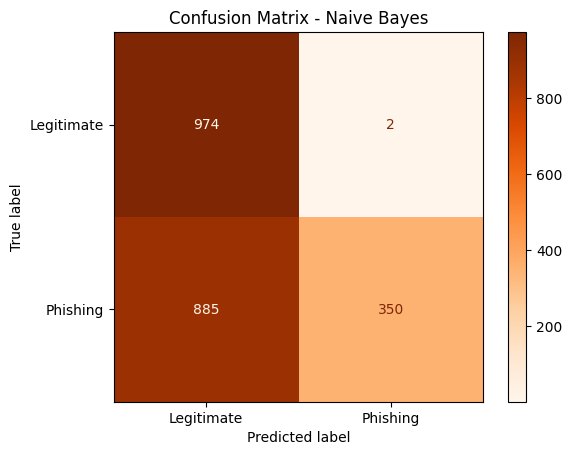


False Positives (Legitimate marked as Phishing): 2
False Negatives (Phishing marked as Legitimate): 885
True Negatives (Legitimate correctly identified): 974
True Positives (Phishing correctly identified): 350


In [45]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

print(f"\nFalse Positives (Legitimate marked as Phishing): {cm[0][1]}")
print(f"False Negatives (Phishing marked as Legitimate): {cm[1][0]}")
print(f"True Negatives (Legitimate correctly identified): {cm[0][0]}")
print(f"True Positives (Phishing correctly identified): {cm[1][1]}")

In [46]:
# FIXED: Storing TEST metrics (not training)
storeResults('Naive Bayes Classifier', acc_test_nb, f1_score_test_nb,
             recall_score_test_nb, precision_score_test_nb)  # ← FIXED!

## 5.5. Decision Trees : Classifier

Decision Tree is a Supervised learning technique that can be used for both classification and Regression problems, but mostly it is preferred for solving Classification problems. It is a tree-structured classifier, where internal nodes represent the features of a dataset, branches represent the decision rules and each leaf node represents the outcome.

Finding optimal max_depth for Decision Tree...


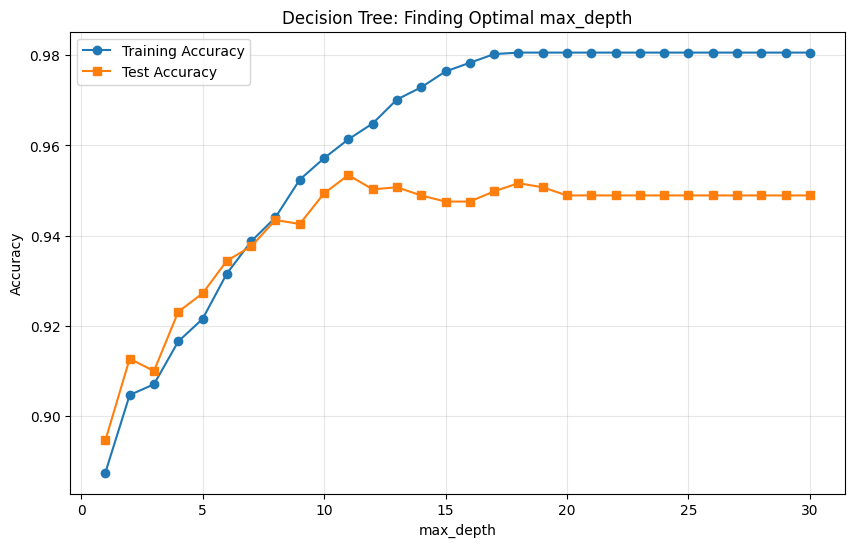


Optimal max_depth: 11
Best test accuracy: 0.953


In [47]:
# Decision Tree Classifier model with optimal hyperparameters
from sklearn.tree import DecisionTreeClassifier

# First, find the optimal max_depth
training_accuracy = []
test_accuracy = []
depth_range = range(1, 31)

print("Finding optimal max_depth for Decision Tree...")
for n in depth_range:
    tree_test = DecisionTreeClassifier(
        max_depth=n,
        random_state=42,
        min_samples_split=5,  # Prevent overfitting
        min_samples_leaf=2     # Prevent overfitting
    )
    tree_test.fit(X_train, y_train)
    training_accuracy.append(tree_test.score(X_train, y_train))
    test_accuracy.append(tree_test.score(X_test, y_test))

# Plot to find optimal depth
plt.figure(figsize=(10, 6))
plt.plot(depth_range, training_accuracy, label="Training Accuracy", marker='o')
plt.plot(depth_range, test_accuracy, label="Test Accuracy", marker='s')
plt.ylabel("Accuracy")
plt.xlabel("max_depth")
plt.title("Decision Tree: Finding Optimal max_depth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Find optimal depth
optimal_depth = depth_range[test_accuracy.index(max(test_accuracy))]
print(f"\nOptimal max_depth: {optimal_depth}")
print(f"Best test accuracy: {max(test_accuracy):.3f}")

In [48]:
# Train final model with optimal depth and additional parameters to prevent overfitting
tree = DecisionTreeClassifier(
    max_depth=optimal_depth,
    min_samples_split=5,      # Require at least 5 samples to split
    min_samples_leaf=2,        # Require at least 2 samples in leaf nodes
    max_features='sqrt',       # Use sqrt of features for each split
    random_state=42
)

# Fit the model
tree.fit(X_train, y_train)

print(f"Decision Tree trained with max_depth={optimal_depth}")

Decision Tree trained with max_depth=11


In [49]:
# Predicting the target value from the model for the samples
y_train_tree = tree.predict(X_train)
y_test_tree = tree.predict(X_test)

In [50]:
# Computing the accuracy, f1_score, Recall, precision of the model performance
acc_train_tree = metrics.accuracy_score(y_train, y_train_tree)
acc_test_tree = metrics.accuracy_score(y_test, y_test_tree)
print("Decision Tree : Accuracy on training Data: {:.3f}".format(acc_train_tree))
print("Decision Tree : Accuracy on test Data: {:.3f}".format(acc_test_tree))
print()

f1_score_train_tree = metrics.f1_score(y_train, y_train_tree)
f1_score_test_tree = metrics.f1_score(y_test, y_test_tree)
print("Decision Tree : f1_score on training Data: {:.3f}".format(f1_score_train_tree))
print("Decision Tree : f1_score on test Data: {:.3f}".format(f1_score_test_tree))
print()

recall_score_train_tree = metrics.recall_score(y_train, y_train_tree)
recall_score_test_tree = metrics.recall_score(y_test, y_test_tree)
print("Decision Tree : Recall on training Data: {:.3f}".format(recall_score_train_tree))
print("Decision Tree : Recall on test Data: {:.3f}".format(recall_score_test_tree))
print()

precision_score_train_tree = metrics.precision_score(y_train, y_train_tree)
precision_score_test_tree = metrics.precision_score(y_test, y_test_tree)
print("Decision Tree : precision on training Data: {:.3f}".format(precision_score_train_tree))
print("Decision Tree : precision on test Data: {:.3f}".format(precision_score_test_tree))

Decision Tree : Accuracy on training Data: 0.916
Decision Tree : Accuracy on test Data: 0.904

Decision Tree : f1_score on training Data: 0.924
Decision Tree : f1_score on test Data: 0.913

Decision Tree : Recall on training Data: 0.926
Decision Tree : Recall on test Data: 0.904

Decision Tree : precision on training Data: 0.922
Decision Tree : precision on test Data: 0.923


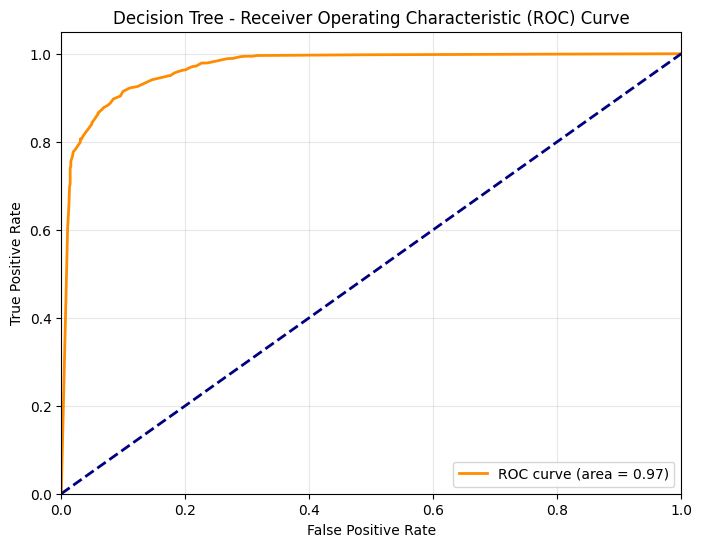

AUC-ROC Score: 0.970


In [51]:
# ROC Curve with probability predictions
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get probability predictions for proper ROC curve
y_test_tree_proba = tree.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_test, y_test_tree_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree - Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"AUC-ROC Score: {roc_auc:.3f}")

In [52]:
# Classification report
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_test_tree))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       976
           1       0.92      0.90      0.91      1235

    accuracy                           0.90      2211
   macro avg       0.90      0.90      0.90      2211
weighted avg       0.90      0.90      0.90      2211



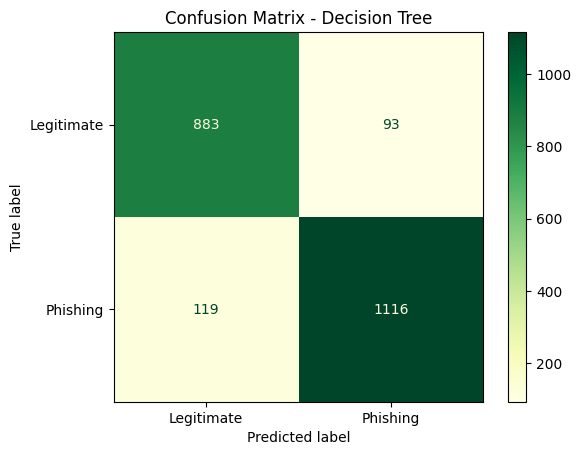


False Positives (Legitimate marked as Phishing): 93
False Negatives (Phishing marked as Legitimate): 119
True Negatives (Legitimate correctly identified): 883
True Positives (Phishing correctly identified): 1116


In [53]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='YlGn')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

print(f"\nFalse Positives (Legitimate marked as Phishing): {cm[0][1]}")
print(f"False Negatives (Phishing marked as Legitimate): {cm[1][0]}")
print(f"True Negatives (Legitimate correctly identified): {cm[0][0]}")
print(f"True Positives (Phishing correctly identified): {cm[1][1]}")


Top 10 Most Important Features:
              feature  importance
7               HTTPS    0.202768
6          SubDomains    0.180509
25     WebsiteTraffic    0.179774
13          AnchorURL    0.147885
5       PrefixSuffix-    0.086777
15  ServerFormHandler    0.027297
26           PageRank    0.022113
0             UsingIP    0.018264
12         RequestURL    0.016235
14  LinksInScriptTags    0.016011


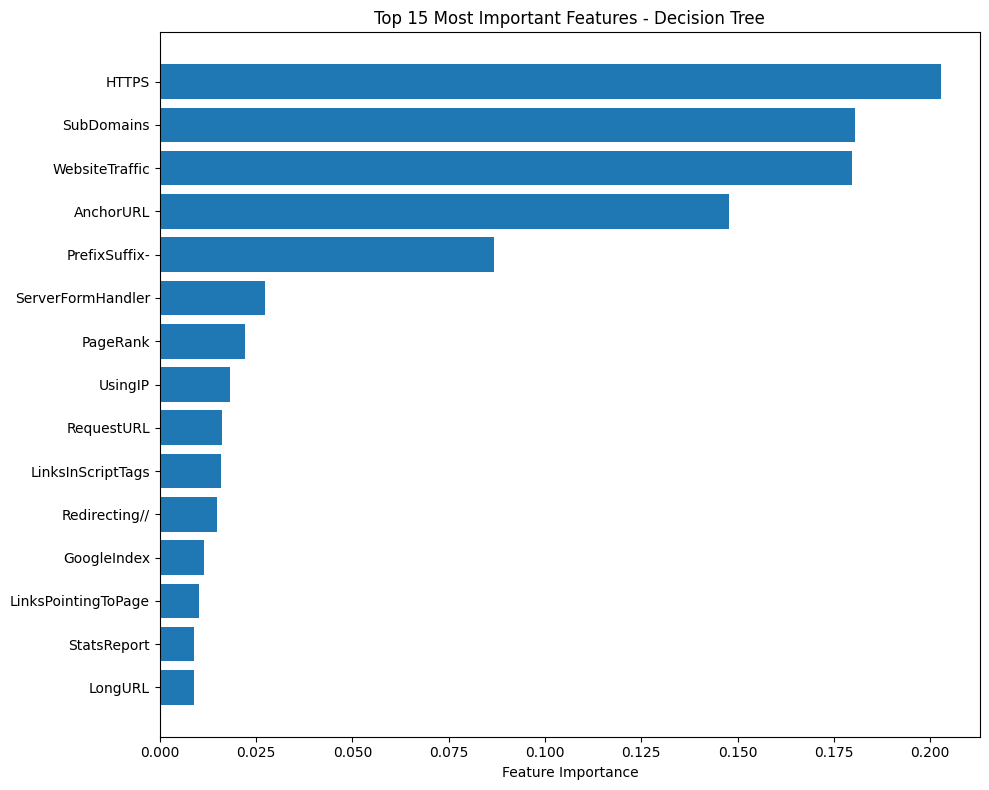

In [54]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': tree.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Most Important Features - Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [55]:
# FIXED: Storing TEST metrics (not training)
storeResults('Decision Tree', acc_test_tree, f1_score_test_tree,
             recall_score_test_tree, precision_score_test_tree)  # ← FIXED!

## 5.6. Random Forest : Classifier

Random Forest is a popular machine learning algorithm that belongs to the supervised learning technique. It can be used for both Classification and Regression problems in ML. It is based on the concept of ensemble learning, which is a process of combining multiple classifiers to solve a complex problem and to improve the performance of the model.

#### 5.6.1 HyperTuning Random Forest Classifier

In [56]:
# Random Forest Classifier with Bayesian Optimization
from sklearn.ensemble import RandomForestClassifier
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

print("Starting Bayesian Optimization for Random Forest...")
print("This will find the best hyperparameters. May take a few minutes.\n")

# Define the model
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Set up the parameter space
param_space = {
    'n_estimators': Integer(100, 300),
    'max_features': Categorical(['sqrt', 'log2']),
    'max_depth': Integer(10, 30),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 4),
    'max_samples': Real(0.7, 1.0)  # Bootstrap sample size
}

# Set up BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=rf_model,
    search_spaces=param_space,
    n_iter=30,
    cv=5,
    scoring='f1',  # Optimize for F1 score
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the Bayesian search
bayes_search.fit(X_train, y_train)

# Display best parameters
print("\n" + "="*50)
print("BEST HYPERPARAMETERS FOUND:")
print("="*50)
for param, value in bayes_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest CV F1 Score: {bayes_search.best_score_:.3f}")
print("="*50 + "\n")

# Use the best model
forest = bayes_search.best_estimator_

Starting Bayesian Optimization for Random Forest...
This will find the best hyperparameters. May take a few minutes.

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

#### 5.6.2 Normal Random Forest Model

In [57]:
# Predicting with the optimized model
y_train_forest = forest.predict(X_train)
y_test_forest = forest.predict(X_test)

In [58]:
# Computing the accuracy, f1_score, Recall, precision of the model performance
acc_train_forest = metrics.accuracy_score(y_train, y_train_forest)
acc_test_forest = metrics.accuracy_score(y_test, y_test_forest)
print("Random Forest (Optimized) : Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random Forest (Optimized) : Accuracy on test Data: {:.3f}".format(acc_test_forest))
print()

f1_score_train_forest = metrics.f1_score(y_train, y_train_forest)
f1_score_test_forest = metrics.f1_score(y_test, y_test_forest)
print("Random Forest (Optimized) : f1_score on training Data: {:.3f}".format(f1_score_train_forest))
print("Random Forest (Optimized) : f1_score on test Data: {:.3f}".format(f1_score_test_forest))
print()

recall_score_train_forest = metrics.recall_score(y_train, y_train_forest)
recall_score_test_forest = metrics.recall_score(y_test, y_test_forest)
print("Random Forest (Optimized) : Recall on training Data: {:.3f}".format(recall_score_train_forest))
print("Random Forest (Optimized) : Recall on test Data: {:.3f}".format(recall_score_test_forest))
print()

precision_score_train_forest = metrics.precision_score(y_train, y_train_forest)
precision_score_test_forest = metrics.precision_score(y_test, y_test_forest)
print("Random Forest (Optimized) : precision on training Data: {:.3f}".format(precision_score_train_forest))
print("Random Forest (Optimized) : precision on test Data: {:.3f}".format(precision_score_test_forest))

Random Forest (Optimized) : Accuracy on training Data: 0.989
Random Forest (Optimized) : Accuracy on test Data: 0.970

Random Forest (Optimized) : f1_score on training Data: 0.990
Random Forest (Optimized) : f1_score on test Data: 0.973

Random Forest (Optimized) : Recall on training Data: 0.993
Random Forest (Optimized) : Recall on test Data: 0.980

Random Forest (Optimized) : precision on training Data: 0.987
Random Forest (Optimized) : precision on test Data: 0.966


#### 5.6.3 Normal Random Forest Model ROC Curve

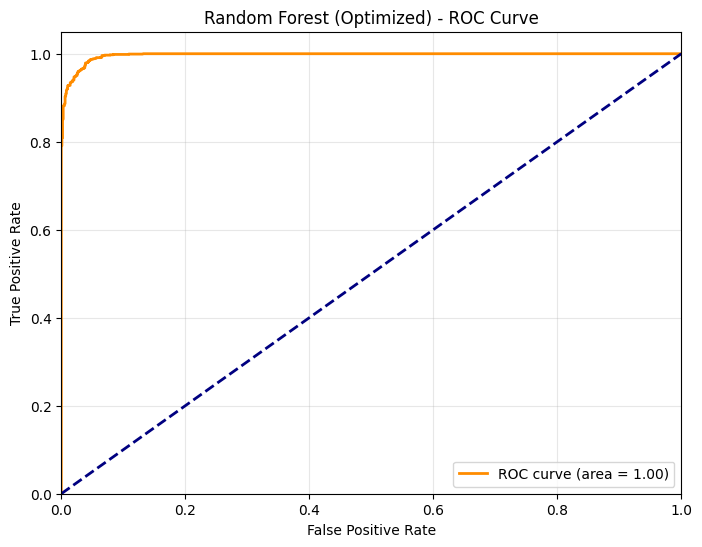

AUC-ROC Score: 0.997


In [59]:
# ROC Curve with probability predictions
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get probability predictions for proper ROC curve
y_test_forest_proba = forest.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_test, y_test_forest_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest (Optimized) - ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"AUC-ROC Score: {roc_auc:.3f}")

#### 5.6.4 HyperTuned Random Forest Model ROC Curve

In [60]:
# Classification report
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_test_forest))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       976
           1       0.97      0.98      0.97      1235

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



#### 5.6.5 Graphs for Normal Random Forest Models for different Parameters

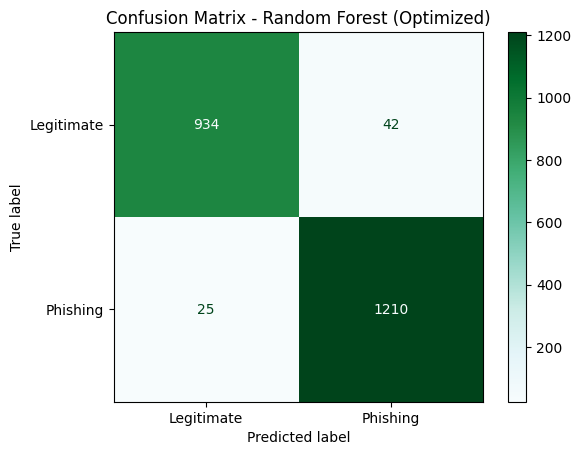


False Positives (Legitimate marked as Phishing): 42
False Negatives (Phishing marked as Legitimate): 25
True Negatives (Legitimate correctly identified): 934
True Positives (Phishing correctly identified): 1210


In [61]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_forest)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='BuGn')
plt.title('Confusion Matrix - Random Forest (Optimized)')
plt.show()

print(f"\nFalse Positives (Legitimate marked as Phishing): {cm[0][1]}")
print(f"False Negatives (Phishing marked as Legitimate): {cm[1][0]}")
print(f"True Negatives (Legitimate correctly identified): {cm[0][0]}")
print(f"True Positives (Phishing correctly identified): {cm[1][1]}")


Top 15 Most Important Features:
                feature  importance
7                 HTTPS    0.302116
13            AnchorURL    0.243867
25       WebsiteTraffic    0.077547
6            SubDomains    0.063475
5         PrefixSuffix-    0.048273
14    LinksInScriptTags    0.042220
15    ServerFormHandler    0.023352
12           RequestURL    0.021738
8          DomainRegLen    0.019082
28  LinksPointingToPage    0.019068
23          AgeofDomain    0.014195
0               UsingIP    0.014100
27          GoogleIndex    0.013114
26             PageRank    0.012256
24         DNSRecording    0.011624


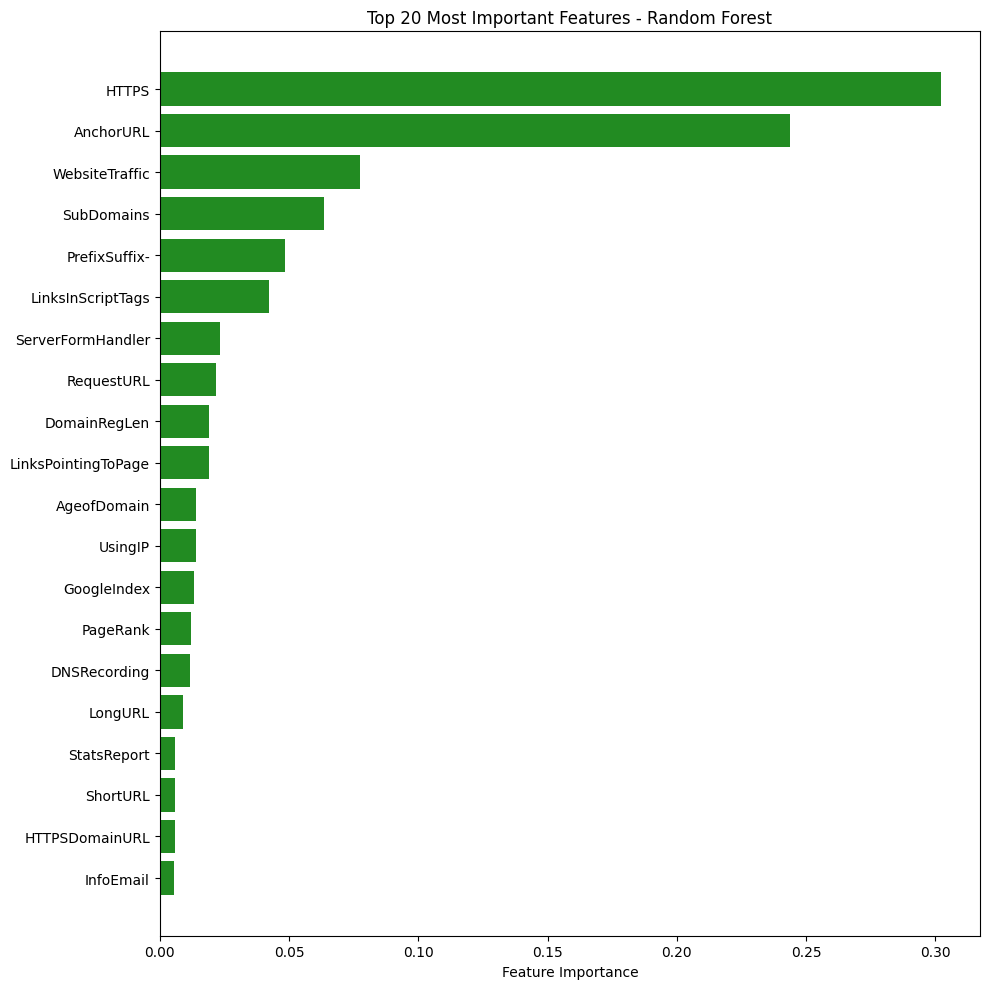

In [62]:
# Feature Importance Analysis - CRITICAL for understanding your model
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': forest.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15))

# Plot top 20 features
plt.figure(figsize=(10, 10))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'], color='forestgreen')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Features - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Testing different n_estimators values...


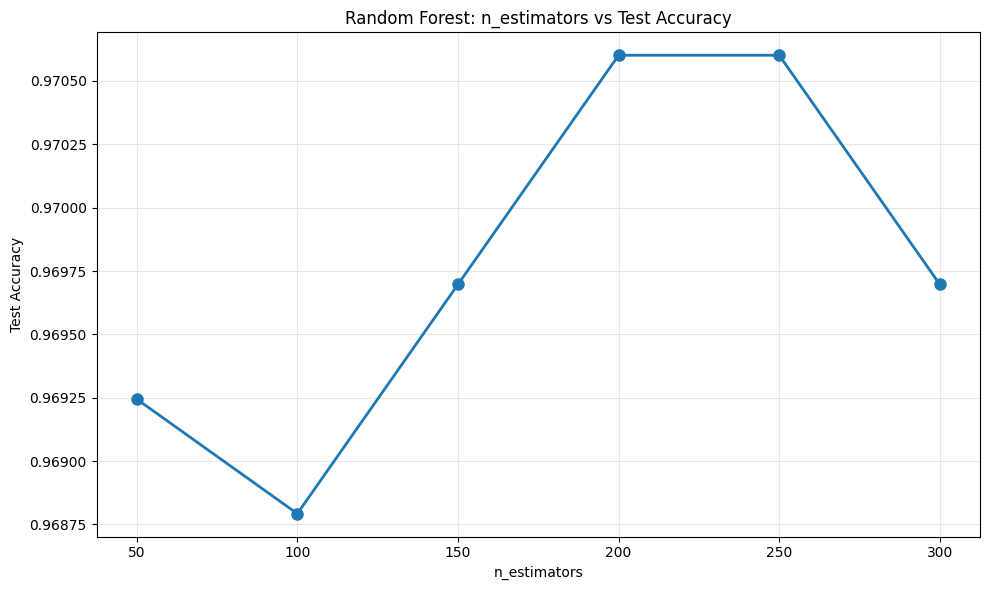

Optimal n_estimators: 200


In [63]:
# Optional: Visualize n_estimators impact (simplified version)
print("\nTesting different n_estimators values...")
n_estimators_range = [50, 100, 150, 200, 250, 300]
test_scores = []

for n in n_estimators_range:
    rf_temp = RandomForestClassifier(
        n_estimators=n,
        max_depth=bayes_search.best_params_['max_depth'],
        max_features=bayes_search.best_params_['max_features'],
        random_state=42,
        n_jobs=-1
    )
    rf_temp.fit(X_train, y_train)
    test_scores.append(rf_temp.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, test_scores, marker='o', linewidth=2, markersize=8)
plt.xlabel('n_estimators')
plt.ylabel('Test Accuracy')
plt.title('Random Forest: n_estimators vs Test Accuracy')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal n_estimators: {n_estimators_range[test_scores.index(max(test_scores))]}")

In [64]:
# Storing TEST metrics (FIXED)
storeResults('Random Forest', acc_test_forest, f1_score_test_forest,
             recall_score_test_forest, precision_score_test_forest)

## 5.7.Gradient Boosting Classifier
Gradient boosting classifiers are a group of machine learning algorithms that combine many weak learning models together to create a strong predictive model. Decision trees are usually used when doing gradient boosting. Boosting algorithms play a crucial role in dealing with bias variance trade-off.  Unlike bagging algorithms, which only controls for high variance in a model, boosting controls both the aspects (bias & variance), and is considered to be more effective.

#### 5.7.1 HyperTuning GBC

In [65]:
# Gradient Boosting Classifier with Bayesian Optimization
from sklearn.ensemble import GradientBoostingClassifier
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

print("Starting Bayesian Optimization for Gradient Boosting Classifier...")
print("This will find the best hyperparameters. May take several minutes.\n")

# Define the model
gbc_model = GradientBoostingClassifier(random_state=42)

# Set up the parameter space
param_space = {
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(3, 10),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 4),
    'max_features': Categorical(['sqrt', 'log2', None]),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'subsample': Real(0.7, 1.0),
    'max_leaf_nodes': Integer(10, 50)
}

# Set up BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=gbc_model,
    search_spaces=param_space,
    n_iter=30,
    cv=5,
    scoring='f1',  # Optimize for F1 score
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the BayesSearchCV
bayes_search.fit(X_train, y_train)

# Display best parameters
print("\n" + "="*50)
print("BEST HYPERPARAMETERS FOUND:")
print("="*50)
for param, value in bayes_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest CV F1 Score: {bayes_search.best_score_:.3f}")
print("="*50 + "\n")

# Use the best model
gbc = bayes_search.best_estimator_

Starting Bayesian Optimization for Gradient Boosting Classifier...
This will find the best hyperparameters. May take several minutes.

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidate

#### 5.7.2 Normal GBC

In [66]:
# Predicting with the optimized model
y_train_gbc = gbc.predict(X_train)
y_test_gbc = gbc.predict(X_test)

In [67]:
# Computing the accuracy, f1_score, Recall, precision of the model performance
acc_train_gbc = metrics.accuracy_score(y_train, y_train_gbc)
acc_test_gbc = metrics.accuracy_score(y_test, y_test_gbc)
print("Gradient Boosting Classifier (Optimized) : Accuracy on training Data: {:.3f}".format(acc_train_gbc))
print("Gradient Boosting Classifier (Optimized) : Accuracy on test Data: {:.3f}".format(acc_test_gbc))
print()

f1_score_train_gbc = metrics.f1_score(y_train, y_train_gbc)
f1_score_test_gbc = metrics.f1_score(y_test, y_test_gbc)
print("Gradient Boosting Classifier (Optimized) : f1_score on training Data: {:.3f}".format(f1_score_train_gbc))
print("Gradient Boosting Classifier (Optimized) : f1_score on test Data: {:.3f}".format(f1_score_test_gbc))
print()

recall_score_train_gbc = metrics.recall_score(y_train, y_train_gbc)
recall_score_test_gbc = metrics.recall_score(y_test, y_test_gbc)
print("Gradient Boosting Classifier (Optimized) : Recall on training Data: {:.3f}".format(recall_score_train_gbc))
print("Gradient Boosting Classifier (Optimized) : Recall on test Data: {:.3f}".format(recall_score_test_gbc))
print()

precision_score_train_gbc = metrics.precision_score(y_train, y_train_gbc)
precision_score_test_gbc = metrics.precision_score(y_test, y_test_gbc)
print("Gradient Boosting Classifier (Optimized) : precision on training Data: {:.3f}".format(precision_score_train_gbc))
print("Gradient Boosting Classifier (Optimized) : precision on test Data: {:.3f}".format(precision_score_test_gbc))

Gradient Boosting Classifier (Optimized) : Accuracy on training Data: 0.991
Gradient Boosting Classifier (Optimized) : Accuracy on test Data: 0.971

Gradient Boosting Classifier (Optimized) : f1_score on training Data: 0.992
Gradient Boosting Classifier (Optimized) : f1_score on test Data: 0.974

Gradient Boosting Classifier (Optimized) : Recall on training Data: 0.994
Gradient Boosting Classifier (Optimized) : Recall on test Data: 0.981

Gradient Boosting Classifier (Optimized) : precision on training Data: 0.990
Gradient Boosting Classifier (Optimized) : precision on test Data: 0.967


#### 5.7.3 ROC Curve for Normal GBC

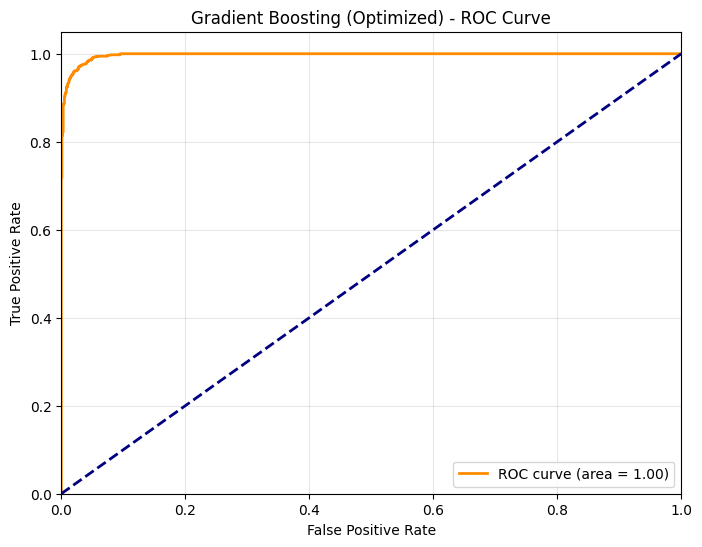

AUC-ROC Score: 0.997


In [68]:
# ROC Curve with probability predictions
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get probability predictions for proper ROC curve
y_test_gbc_proba = gbc.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_test, y_test_gbc_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Gradient Boosting (Optimized) - ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"AUC-ROC Score: {roc_auc:.3f}")

#### 5.7.4 ROC Curve for HyperTuned GBC

In [69]:
# Classification report
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_test_gbc))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       976
           1       0.97      0.98      0.97      1235

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



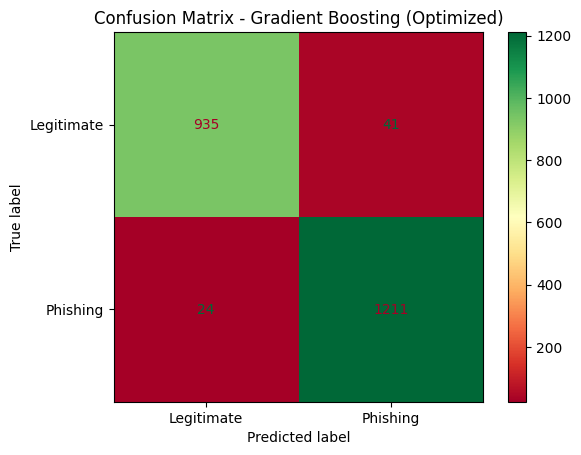


False Positives (Legitimate marked as Phishing): 41
False Negatives (Phishing marked as Legitimate): 24
True Negatives (Legitimate correctly identified): 935
True Positives (Phishing correctly identified): 1211


In [70]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_gbc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='RdYlGn')
plt.title('Confusion Matrix - Gradient Boosting (Optimized)')
plt.show()

print(f"\nFalse Positives (Legitimate marked as Phishing): {cm[0][1]}")
print(f"False Negatives (Phishing marked as Legitimate): {cm[1][0]}")
print(f"True Negatives (Legitimate correctly identified): {cm[0][0]}")
print(f"True Positives (Phishing correctly identified): {cm[1][1]}")


Top 15 Most Important Features:
                feature  importance
7                 HTTPS    0.326922
13            AnchorURL    0.261498
25       WebsiteTraffic    0.107596
5         PrefixSuffix-    0.062584
6            SubDomains    0.052677
14    LinksInScriptTags    0.040622
15    ServerFormHandler    0.016874
28  LinksPointingToPage    0.012659
12           RequestURL    0.012046
24         DNSRecording    0.011846
0               UsingIP    0.010836
8          DomainRegLen    0.009638
27          GoogleIndex    0.009496
23          AgeofDomain    0.008022
1               LongURL    0.007408


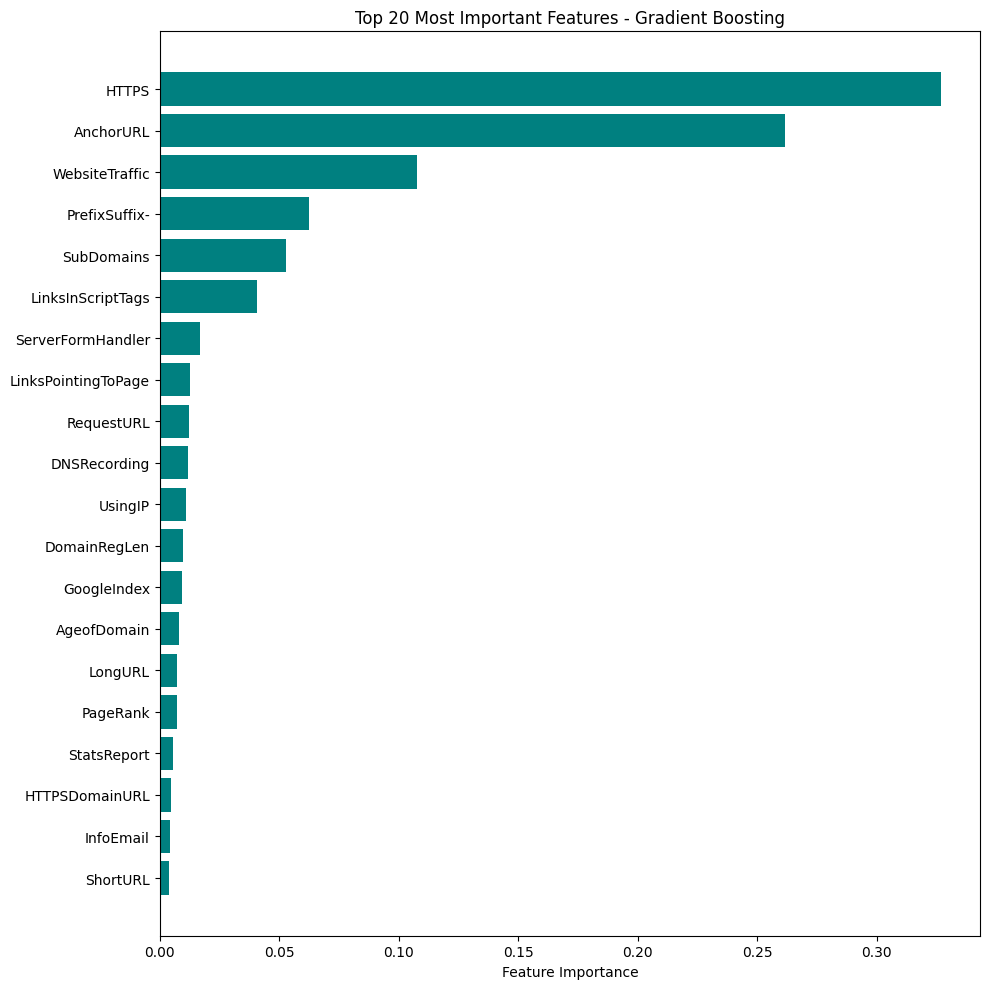

In [71]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': gbc.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15))

# Plot top 20 features
plt.figure(figsize=(10, 10))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'], color='teal')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Features - Gradient Boosting')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

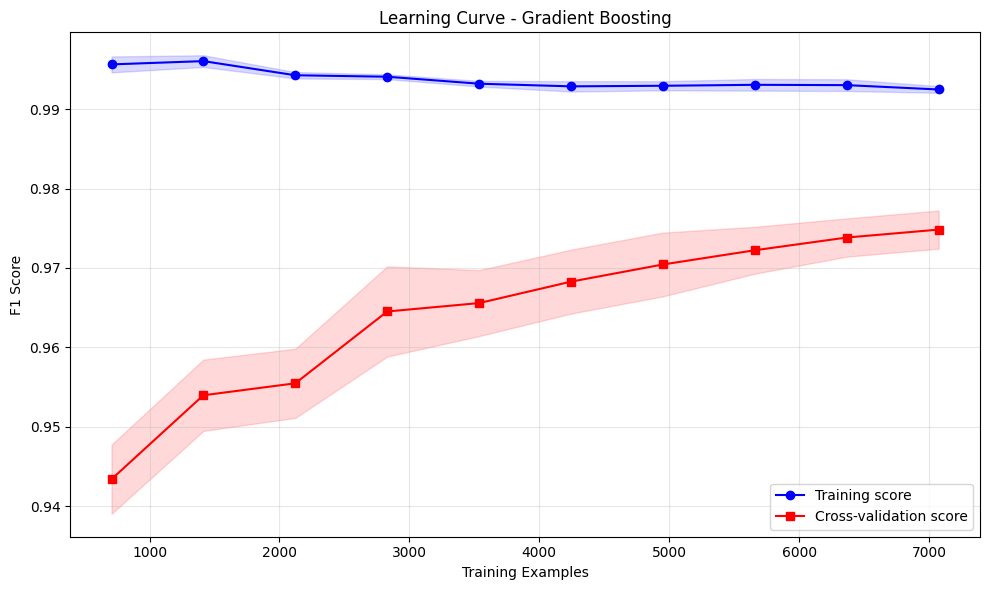

In [72]:
# Learning curve analysis - understanding model behavior
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    gbc, X_train, y_train, 
    cv=5, 
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1'
)

# Calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training score', color='blue', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, test_mean, label='Cross-validation score', color='red', marker='s')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='red')
plt.xlabel('Training Examples')
plt.ylabel('F1 Score')
plt.title('Learning Curve - Gradient Boosting')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Analyzing learning_rate impact...


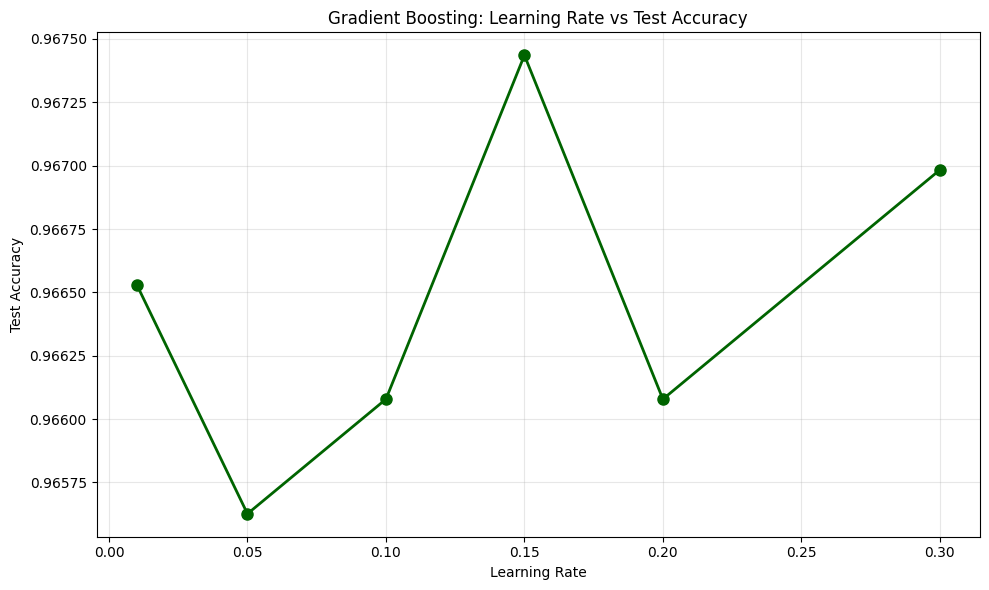

Optimal learning_rate: 0.15


In [73]:
# Optional: Visualize impact of key hyperparameters
print("\nAnalyzing learning_rate impact...")
learning_rates = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3]
lr_test_scores = []

for lr in learning_rates:
    gbc_temp = GradientBoostingClassifier(
        learning_rate=lr,
        n_estimators=bayes_search.best_params_['n_estimators'],
        max_depth=bayes_search.best_params_['max_depth'],
        random_state=42
    )
    gbc_temp.fit(X_train, y_train)
    lr_test_scores.append(gbc_temp.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(learning_rates, lr_test_scores, marker='o', linewidth=2, markersize=8, color='darkgreen')
plt.xlabel('Learning Rate')
plt.ylabel('Test Accuracy')
plt.title('Gradient Boosting: Learning Rate vs Test Accuracy')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal learning_rate: {learning_rates[lr_test_scores.index(max(lr_test_scores))]}")

In [74]:
# FIXED: Storing TEST metrics (not training)
storeResults('Gradient Boosting Classifier', acc_test_gbc, f1_score_test_gbc,
             recall_score_test_gbc, precision_score_test_gbc)  # ← FIXED!

## 5.8. CatBoost Classifier

CatBoost is a recently open-sourced machine learning algorithm from Yandex. It can easily integrate with deep learning frameworks like Google’s TensorFlow and Apple’s Core ML. It can work with diverse data types to help solve a wide range of problems that businesses face today.

#### 5.8.1 HyperTuning CatBoost Classifier

In [75]:
# CatBoost Classifier with Bayesian Optimization
from catboost import CatBoostClassifier
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

print("Starting Bayesian Optimization for CatBoost Classifier...")
print("CatBoost is powerful for tabular data. This may take several minutes.\n")

# Define the model
cat_model = CatBoostClassifier(
    random_seed=42,
    verbose=0,  # Silent training
    thread_count=-1  # Use all CPU cores
)

# Set up the parameter space
param_space = {
    'depth': Integer(4, 10),
    'iterations': Integer(100, 500),
    'l2_leaf_reg': Real(1e-5, 10, prior='log-uniform'),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'border_count': Categorical([32, 64, 128, 255]),
    'random_strength': Real(1e-9, 10),
    'bagging_temperature': Real(0.0, 1.0),
}

# Set up BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=cat_model,
    search_spaces=param_space,
    n_iter=30,
    cv=5,
    scoring='f1',  # Optimize for F1 score
    verbose=1,
    random_state=42,
    n_jobs=1  # CatBoost handles parallelism internally
)

# Fit the BayesSearchCV
bayes_search.fit(X_train, y_train)

# Display best parameters
print("\n" + "="*50)
print("BEST HYPERPARAMETERS FOUND:")
print("="*50)
for param, value in bayes_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest CV F1 Score: {bayes_search.best_score_:.3f}")
print("="*50 + "\n")

# Use the best model
cat = bayes_search.best_estimator_

Starting Bayesian Optimization for CatBoost Classifier...
CatBoost is powerful for tabular data. This may take several minutes.

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, tot

In [76]:
# Predicting with the optimized model
y_train_cat = cat.predict(X_train)
y_test_cat = cat.predict(X_test)

In [77]:
# Computing the accuracy, f1_score, Recall, precision of the model performance
acc_train_cat = metrics.accuracy_score(y_train, y_train_cat)
acc_test_cat = metrics.accuracy_score(y_test, y_test_cat)
print("CatBoost Classifier (Optimized) : Accuracy on training Data: {:.3f}".format(acc_train_cat))
print("CatBoost Classifier (Optimized) : Accuracy on test Data: {:.3f}".format(acc_test_cat))
print()

f1_score_train_cat = metrics.f1_score(y_train, y_train_cat)
f1_score_test_cat = metrics.f1_score(y_test, y_test_cat)
print("CatBoost Classifier (Optimized) : f1_score on training Data: {:.3f}".format(f1_score_train_cat))
print("CatBoost Classifier (Optimized) : f1_score on test Data: {:.3f}".format(f1_score_test_cat))
print()

recall_score_train_cat = metrics.recall_score(y_train, y_train_cat)
recall_score_test_cat = metrics.recall_score(y_test, y_test_cat)
print("CatBoost Classifier (Optimized) : Recall on training Data: {:.3f}".format(recall_score_train_cat))
print("CatBoost Classifier (Optimized) : Recall on test Data: {:.3f}".format(recall_score_test_cat))
print()

precision_score_train_cat = metrics.precision_score(y_train, y_train_cat)
precision_score_test_cat = metrics.precision_score(y_test, y_test_cat)
print("CatBoost Classifier (Optimized) : precision on training Data: {:.3f}".format(precision_score_train_cat))
print("CatBoost Classifier (Optimized) : precision on test Data: {:.3f}".format(precision_score_test_cat))

CatBoost Classifier (Optimized) : Accuracy on training Data: 0.991
CatBoost Classifier (Optimized) : Accuracy on test Data: 0.971

CatBoost Classifier (Optimized) : f1_score on training Data: 0.992
CatBoost Classifier (Optimized) : f1_score on test Data: 0.974

CatBoost Classifier (Optimized) : Recall on training Data: 0.995
CatBoost Classifier (Optimized) : Recall on test Data: 0.982

CatBoost Classifier (Optimized) : precision on training Data: 0.989
CatBoost Classifier (Optimized) : precision on test Data: 0.967


#### 5.8.3 ROC Curve for Normal CatBoost Classifier

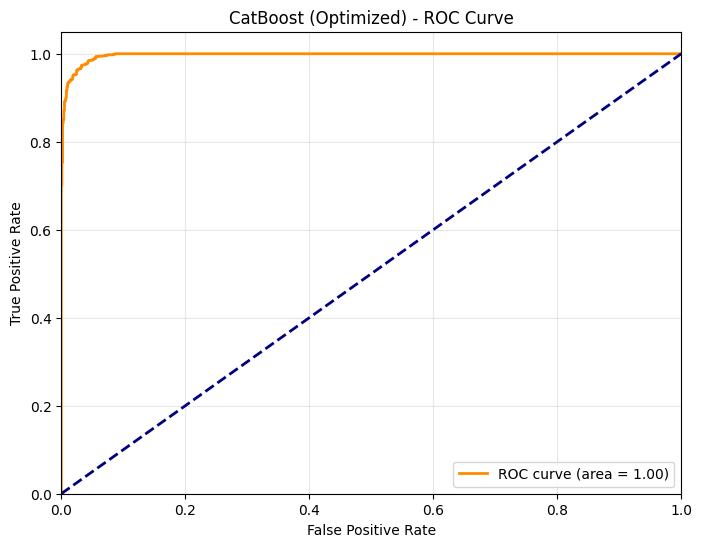

AUC-ROC Score: 0.997


In [78]:
# ROC Curve with probability predictions
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get probability predictions for proper ROC curve
y_test_cat_proba = cat.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_test, y_test_cat_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CatBoost (Optimized) - ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"AUC-ROC Score: {roc_auc:.3f}")

#### 5.8.4 ROC Curve for HyperTuned CatBoost Classifier

In [79]:
# Classification report
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_test_cat))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       976
           1       0.97      0.98      0.97      1235

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



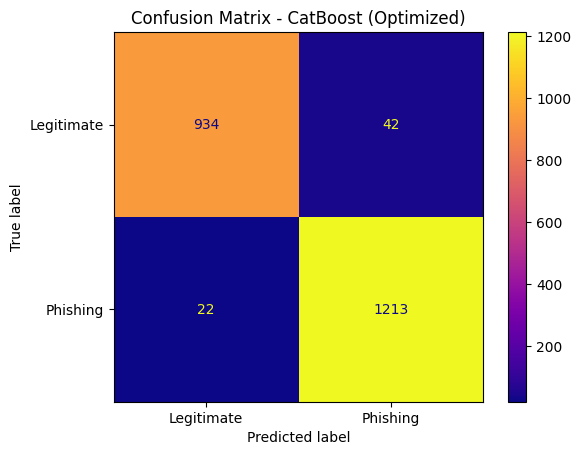


False Positives (Legitimate marked as Phishing): 42
False Negatives (Phishing marked as Legitimate): 22
True Negatives (Legitimate correctly identified): 934
True Positives (Phishing correctly identified): 1213


In [80]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_cat)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='plasma')
plt.title('Confusion Matrix - CatBoost (Optimized)')
plt.show()

print(f"\nFalse Positives (Legitimate marked as Phishing): {cm[0][1]}")
print(f"False Negatives (Phishing marked as Legitimate): {cm[1][0]}")
print(f"True Negatives (Legitimate correctly identified): {cm[0][0]}")
print(f"True Positives (Phishing correctly identified): {cm[1][1]}")


Top 15 Most Important Features:
                feature  importance
13            AnchorURL   18.949172
7                 HTTPS   16.736385
25       WebsiteTraffic    8.752947
14    LinksInScriptTags    7.176270
6            SubDomains    7.098977
5         PrefixSuffix-    5.436230
28  LinksPointingToPage    5.139992
15    ServerFormHandler    4.657131
0               UsingIP    3.329710
23          AgeofDomain    2.917330
12           RequestURL    2.751179
24         DNSRecording    2.719371
1               LongURL    2.587988
26             PageRank    2.168498
8          DomainRegLen    2.028636


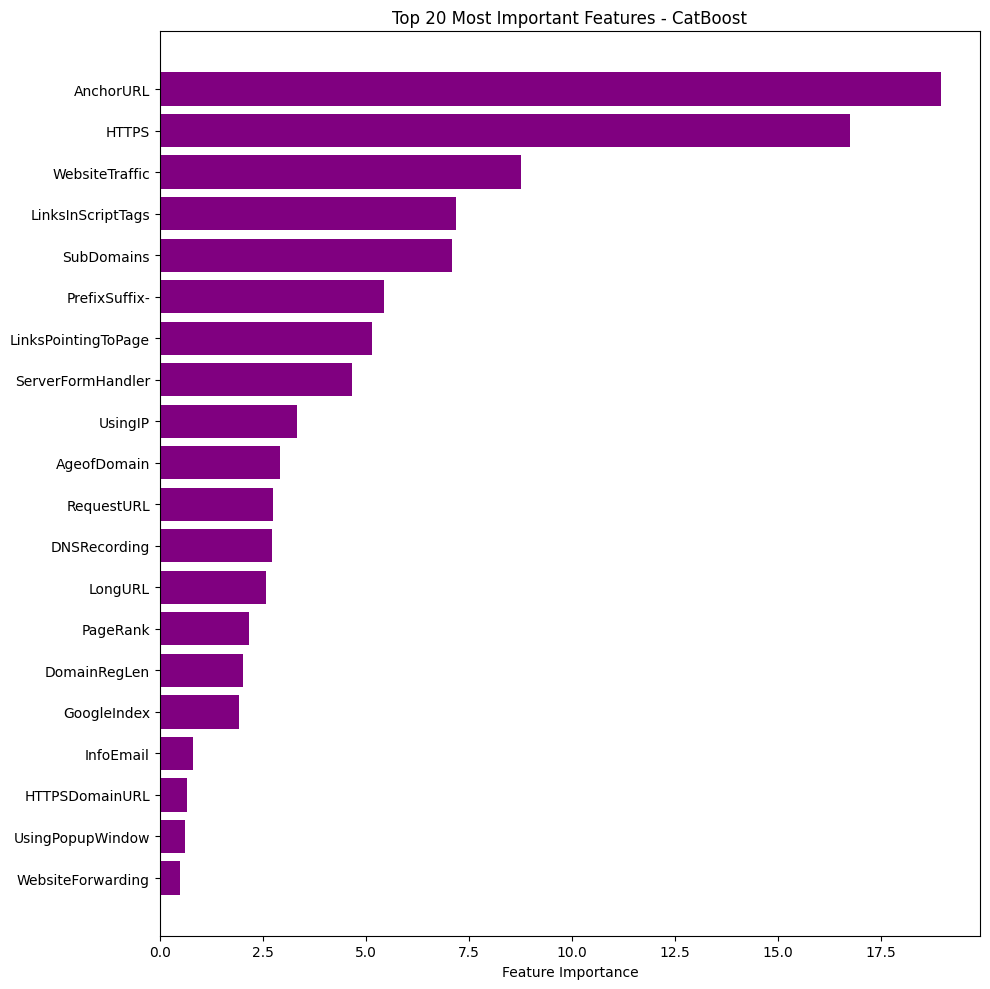

In [81]:
# Feature Importance Analysis - CatBoost provides excellent feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': cat.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15))

# Plot top 20 features
plt.figure(figsize=(10, 10))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'], color='purple')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Features - CatBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Testing different learning rates...


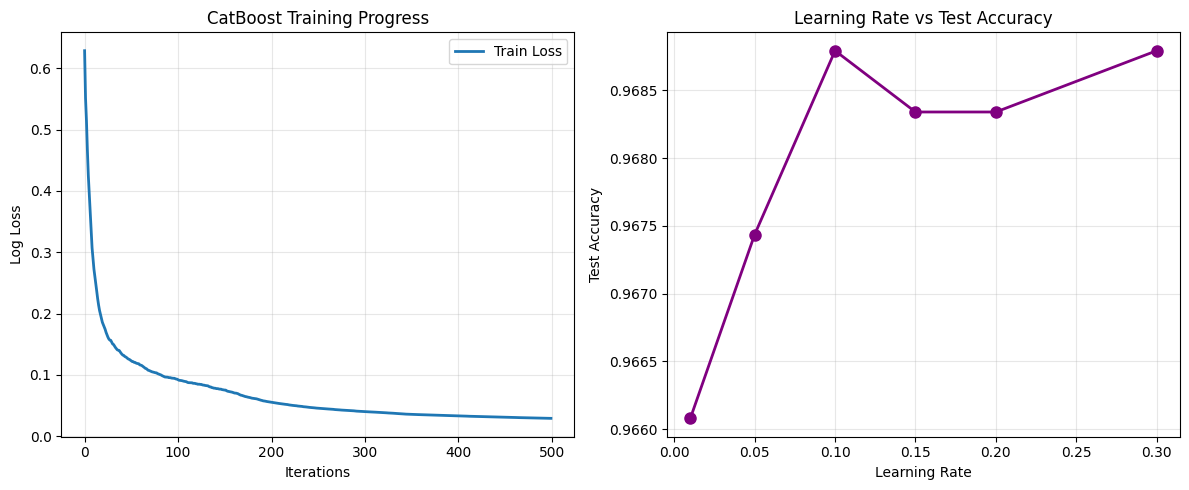

Optimal learning_rate: 0.1


In [82]:
# CatBoost training progress visualization
# This shows how the model improved during training
plt.figure(figsize=(12, 5))

# Plot 1: Best iteration
plt.subplot(1, 2, 1)
plt.plot(cat.evals_result_['learn']['Logloss'], label='Train Loss', linewidth=2)
if 'validation' in cat.evals_result_:
    plt.plot(cat.evals_result_['validation']['Logloss'], label='Validation Loss', linewidth=2)
plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.title('CatBoost Training Progress')
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: Learning rate impact (simplified)
plt.subplot(1, 2, 2)
learning_rates = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3]
lr_test_scores = []

print("\nTesting different learning rates...")
for lr in learning_rates:
    cat_temp = CatBoostClassifier(
        learning_rate=lr,
        iterations=bayes_search.best_params_['iterations'],
        depth=bayes_search.best_params_['depth'],
        random_seed=42,
        verbose=0
    )
    cat_temp.fit(X_train, y_train)
    lr_test_scores.append(cat_temp.score(X_test, y_test))

plt.plot(learning_rates, lr_test_scores, marker='o', linewidth=2, markersize=8, color='purple')
plt.xlabel('Learning Rate')
plt.ylabel('Test Accuracy')
plt.title('Learning Rate vs Test Accuracy')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Optimal learning_rate: {learning_rates[lr_test_scores.index(max(lr_test_scores))]}")

In [83]:
# FIXED: Storing TEST metrics (not training)
storeResults('CatBoost Classifier', acc_test_cat, f1_score_test_cat,
             recall_score_test_cat, precision_score_test_cat)  # ← FIXED!

## 5.9. Multi-layer Perceptron classifier

MLPClassifier stands for Multi-layer Perceptron classifier which in the name itself connects to a Neural Network. Unlike other classification algorithms such as Support Vectors or Naive Bayes Classifier, MLPClassifier relies on an underlying Neural Network to perform the task of classification.


5.9.1 HyperTuning MLP Classifier

In [84]:
# Multi-layer Perceptron Classifier with Randomized Search and Feature Scaling
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

print("Starting Randomized Search for Multi-layer Perceptron (Neural Network)...")
print("Neural networks require scaled features. Using scaled data.\n")

# Define the model
mlp_model = MLPClassifier(
    max_iter=1000,  # Increased iterations
    early_stopping=True,  # Stop when validation score doesn't improve
    validation_fraction=0.1,
    random_state=42
)

# Define the search space for the hyperparameters
param_distributions = {
    'hidden_layer_sizes': [(50,), (100,), (150,), (50, 50), (100, 50), (100, 100)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': uniform(0.0001, 0.01),  # L2 regularization
    'learning_rate_init': uniform(0.001, 0.01),
    'learning_rate': ['constant', 'adaptive']
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=mlp_model,
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    verbose=1,
    scoring='f1',  # Optimize for F1 score
    random_state=42,
    n_jobs=-1
)

# Fit with SCALED data (critical for neural networks!)
random_search.fit(X_train_scaled, y_train)

# Display best parameters
print("\n" + "="*50)
print("BEST HYPERPARAMETERS FOUND:")
print("="*50)
for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest CV F1 Score: {random_search.best_score_:.3f}")
print("="*50 + "\n")

# Use the best model
mlp = random_search.best_estimator_

Starting Randomized Search for Multi-layer Perceptron (Neural Network)...
Neural networks require scaled features. Using scaled data.

Fitting 5 folds for each of 30 candidates, totalling 150 fits

BEST HYPERPARAMETERS FOUND:
activation: relu
alpha: 0.006434037565104235
hidden_layer_sizes: (100, 100)
learning_rate: adaptive
learning_rate_init: 0.009036720768991143
solver: adam

Best CV F1 Score: 0.969



#### 5.9.2 Normal MLP Classifier

In [85]:
# Predicting with the optimized model using SCALED data
y_train_mlp = mlp.predict(X_train_scaled)
y_test_mlp = mlp.predict(X_test_scaled)

In [86]:
# Computing the accuracy, f1_score, Recall, precision of the model performance
acc_train_mlp = metrics.accuracy_score(y_train, y_train_mlp)
acc_test_mlp = metrics.accuracy_score(y_test, y_test_mlp)
print("Multi-layer Perceptron (Optimized) : Accuracy on training Data: {:.3f}".format(acc_train_mlp))
print("Multi-layer Perceptron (Optimized) : Accuracy on test Data: {:.3f}".format(acc_test_mlp))
print()

f1_score_train_mlp = metrics.f1_score(y_train, y_train_mlp)
f1_score_test_mlp = metrics.f1_score(y_test, y_test_mlp)
print("Multi-layer Perceptron (Optimized) : f1_score on training Data: {:.3f}".format(f1_score_train_mlp))
print("Multi-layer Perceptron (Optimized) : f1_score on test Data: {:.3f}".format(f1_score_test_mlp))
print()

recall_score_train_mlp = metrics.recall_score(y_train, y_train_mlp)
recall_score_test_mlp = metrics.recall_score(y_test, y_test_mlp)
print("Multi-layer Perceptron (Optimized) : Recall on training Data: {:.3f}".format(recall_score_train_mlp))
print("Multi-layer Perceptron (Optimized) : Recall on test Data: {:.3f}".format(recall_score_test_mlp))
print()

precision_score_train_mlp = metrics.precision_score(y_train, y_train_mlp)
precision_score_test_mlp = metrics.precision_score(y_test, y_test_mlp)
print("Multi-layer Perceptron (Optimized) : precision on training Data: {:.3f}".format(precision_score_train_mlp))
print("Multi-layer Perceptron (Optimized) : precision on test Data: {:.3f}".format(precision_score_test_mlp))

Multi-layer Perceptron (Optimized) : Accuracy on training Data: 0.983
Multi-layer Perceptron (Optimized) : Accuracy on test Data: 0.967

Multi-layer Perceptron (Optimized) : f1_score on training Data: 0.985
Multi-layer Perceptron (Optimized) : f1_score on test Data: 0.970

Multi-layer Perceptron (Optimized) : Recall on training Data: 0.988
Multi-layer Perceptron (Optimized) : Recall on test Data: 0.976

Multi-layer Perceptron (Optimized) : precision on training Data: 0.983
Multi-layer Perceptron (Optimized) : precision on test Data: 0.965


#### 5.9.3 ROC Curve for Normal MLP Model

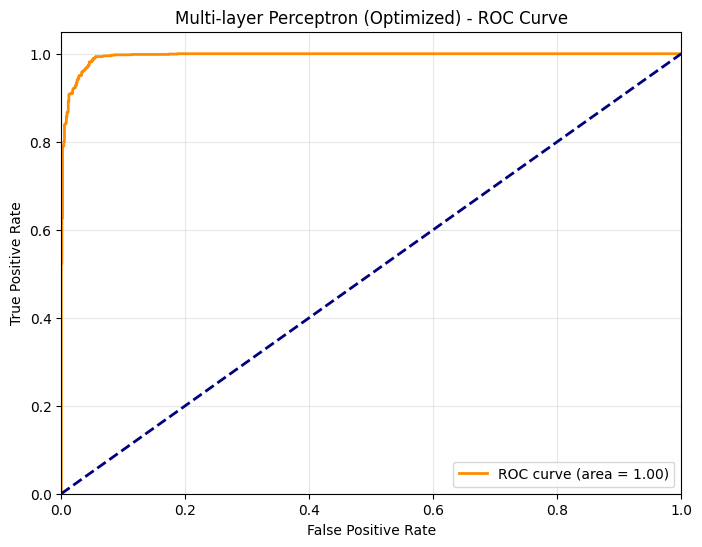

AUC-ROC Score: 0.995


In [87]:
# ROC Curve with probability predictions
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get probability predictions for proper ROC curve
y_test_mlp_proba = mlp.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_test, y_test_mlp_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-layer Perceptron (Optimized) - ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"AUC-ROC Score: {roc_auc:.3f}")

#### 5.9.4 ROC Curve for HyperTuned MLP Model

In [88]:
# Classification report
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_test_mlp))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       976
           1       0.96      0.98      0.97      1235

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



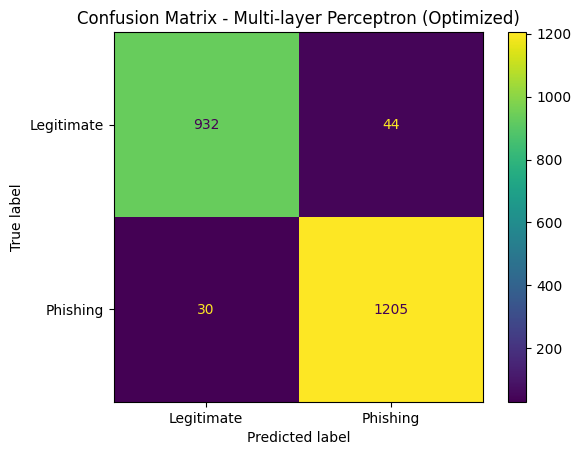


False Positives (Legitimate marked as Phishing): 44
False Negatives (Phishing marked as Legitimate): 30
True Negatives (Legitimate correctly identified): 932
True Positives (Phishing correctly identified): 1205


In [89]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='viridis')
plt.title('Confusion Matrix - Multi-layer Perceptron (Optimized)')
plt.show()

print(f"\nFalse Positives (Legitimate marked as Phishing): {cm[0][1]}")
print(f"False Negatives (Phishing marked as Legitimate): {cm[1][0]}")
print(f"True Negatives (Legitimate correctly identified): {cm[0][0]}")
print(f"True Positives (Phishing correctly identified): {cm[1][1]}")

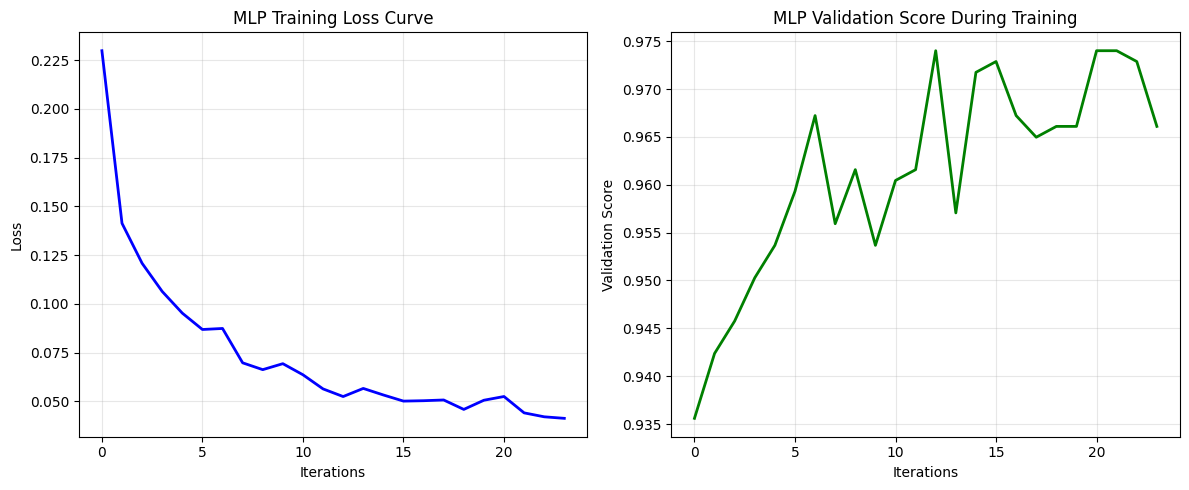


Total iterations: 24
Number of layers: 4
Output activation: logistic


In [90]:
# Neural Network Training Loss Curve
plt.figure(figsize=(12, 5))

# Plot 1: Loss curve
plt.subplot(1, 2, 1)
plt.plot(mlp.loss_curve_, linewidth=2, color='blue')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('MLP Training Loss Curve')
plt.grid(alpha=0.3)

# Plot 2: Validation score (if early stopping was used)
if hasattr(mlp, 'validation_scores_'):
    plt.subplot(1, 2, 2)
    plt.plot(mlp.validation_scores_, linewidth=2, color='green')
    plt.xlabel('Iterations')
    plt.ylabel('Validation Score')
    plt.title('MLP Validation Score During Training')
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTotal iterations: {mlp.n_iter_}")
print(f"Number of layers: {mlp.n_layers_}")
print(f"Output activation: {mlp.out_activation_}")


Testing different neural network architectures...
Architecture (50,): Test Accuracy = 0.958
Architecture (100,): Test Accuracy = 0.966
Architecture (150,): Test Accuracy = 0.966
Architecture (50, 50): Test Accuracy = 0.957
Architecture (100, 50): Test Accuracy = 0.969
Architecture (100, 100): Test Accuracy = 0.967
Architecture (150, 100): Test Accuracy = 0.961


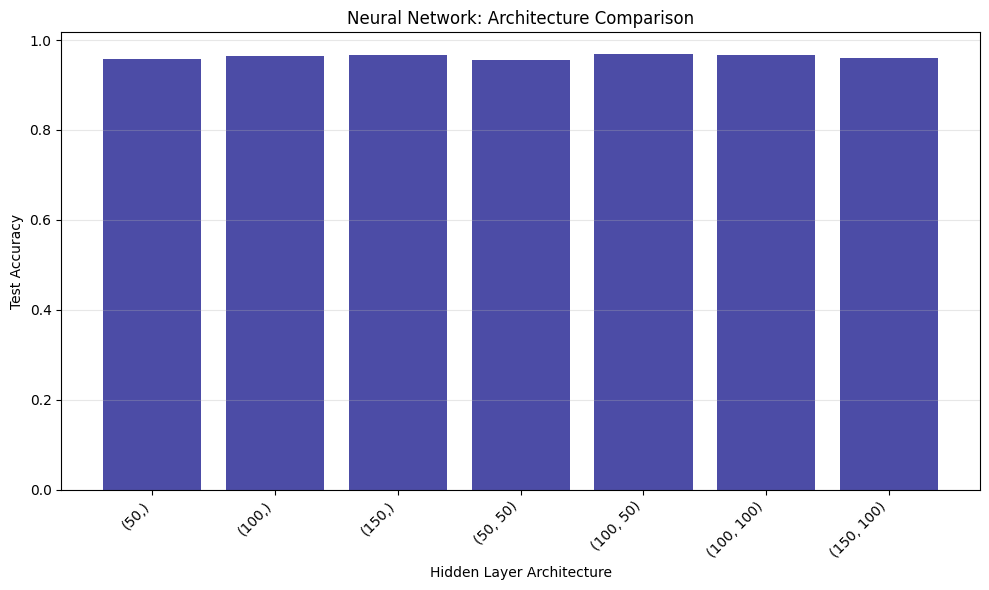


Best architecture: (100, 50) with accuracy 0.969


In [91]:
# Test different hidden layer architectures
print("\nTesting different neural network architectures...")
architectures = [(50,), (100,), (150,), (50, 50), (100, 50), (100, 100), (150, 100)]
arch_scores = []

for arch in architectures:
    mlp_temp = MLPClassifier(
        hidden_layer_sizes=arch,
        activation=random_search.best_params_['activation'],
        solver=random_search.best_params_['solver'],
        alpha=random_search.best_params_['alpha'],
        learning_rate_init=random_search.best_params_['learning_rate_init'],
        max_iter=1000,
        early_stopping=True,
        random_state=42
    )
    mlp_temp.fit(X_train_scaled, y_train)
    arch_scores.append(mlp_temp.score(X_test_scaled, y_test))
    print(f"Architecture {arch}: Test Accuracy = {arch_scores[-1]:.3f}")

# Plot architecture comparison
plt.figure(figsize=(10, 6))
arch_labels = [str(arch) for arch in architectures]
plt.bar(range(len(architectures)), arch_scores, color='navy', alpha=0.7)
plt.xticks(range(len(architectures)), arch_labels, rotation=45, ha='right')
plt.xlabel('Hidden Layer Architecture')
plt.ylabel('Test Accuracy')
plt.title('Neural Network: Architecture Comparison')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

best_arch_idx = arch_scores.index(max(arch_scores))
print(f"\nBest architecture: {architectures[best_arch_idx]} with accuracy {max(arch_scores):.3f}")

In [92]:
# FIXED: Storing TEST metrics (not training)
storeResults('Multi-layer Perceptron', acc_test_mlp, f1_score_test_mlp,
             recall_score_test_mlp, precision_score_test_mlp)  # ← FIXED!


FINAL MODEL COMPARISON - SORTED BY F1-SCORE
                       Model  Accuracy  F1-Score  Recall  Precision
Gradient Boosting Classifier     0.971     0.974   0.981      0.967
         CatBoost Classifier     0.971     0.974   0.982      0.967
               Random Forest     0.970     0.973   0.980      0.966
      Support Vector Machine     0.968     0.972   0.979      0.965
      Multi-layer Perceptron     0.967     0.970   0.976      0.965
         K-Nearest Neighbors     0.959     0.964   0.964      0.964
         Logistic Regression     0.914     0.920   0.888      0.954
               Decision Tree     0.904     0.913   0.904      0.923
      Naive Bayes Classifier     0.599     0.441   0.283      0.994


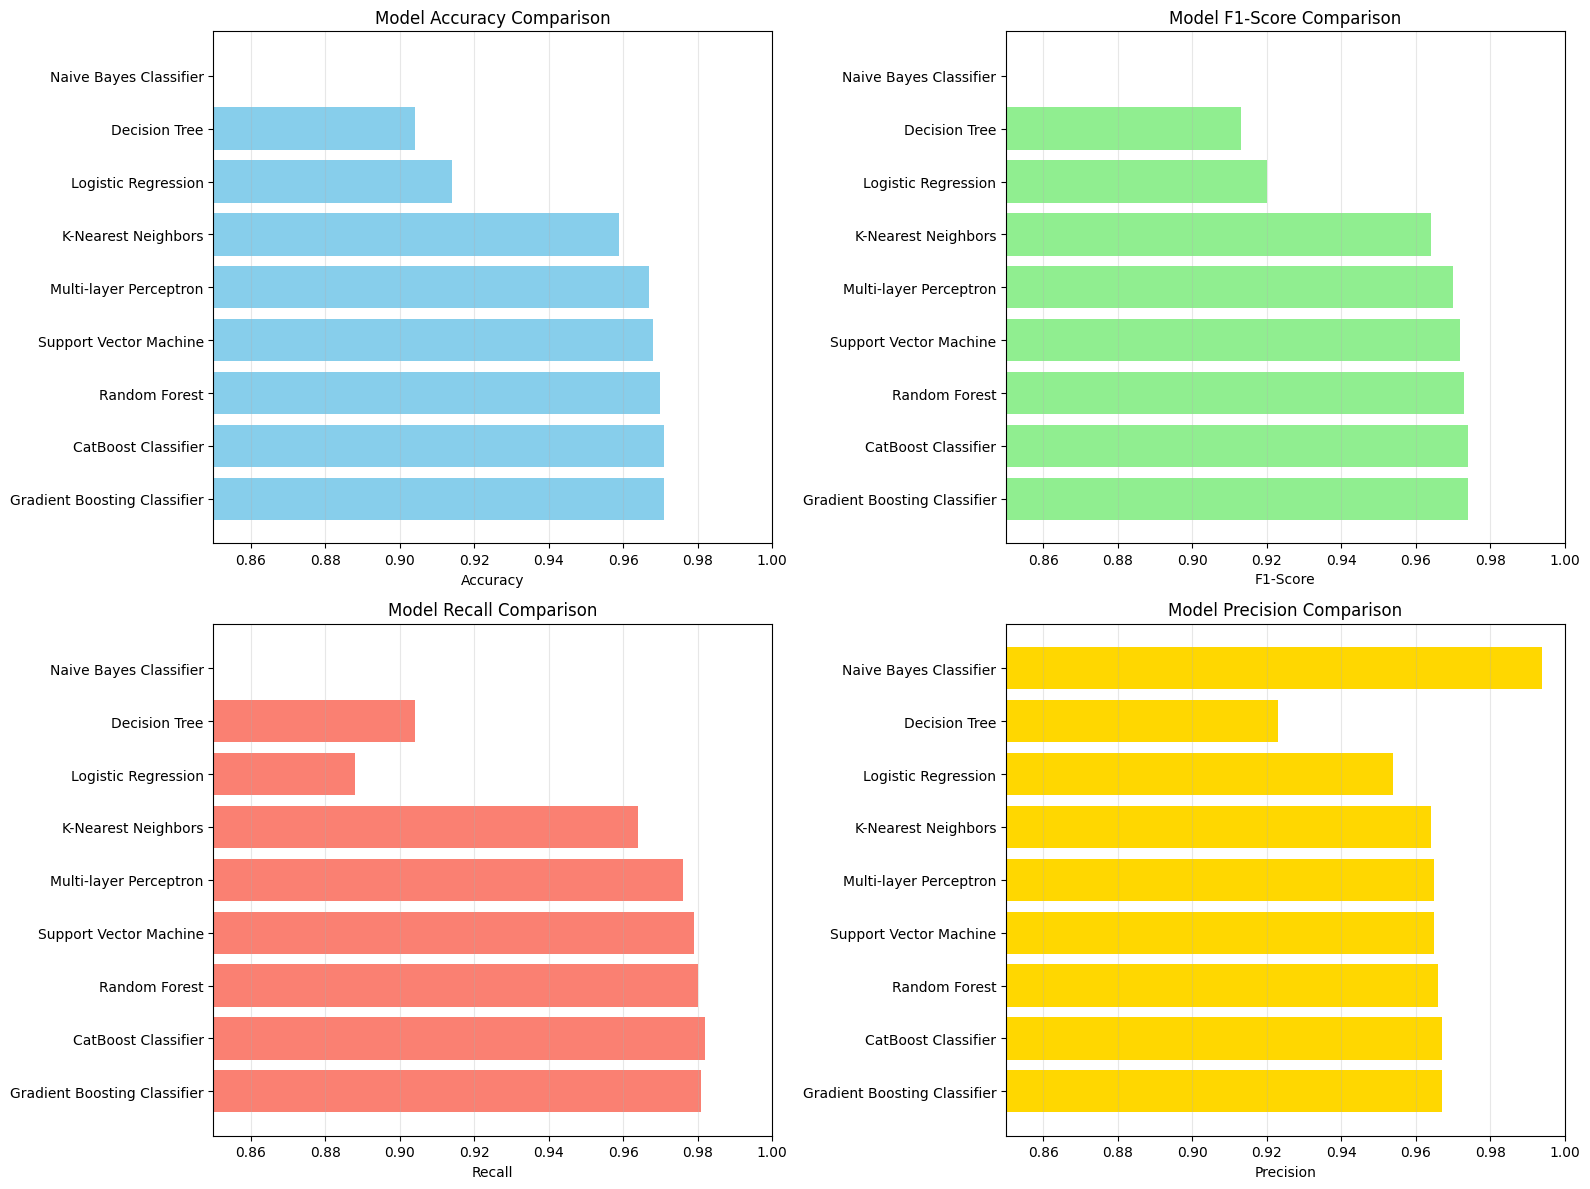


🏆 BEST MODEL: Gradient Boosting Classifier with F1-Score: 0.974


In [93]:
# ============================================
# FINAL MODEL COMPARISON
# ============================================

# Create comparison dataframe
results_df = pd.DataFrame({
    'Model': ML_Model,
    'Accuracy': accuracy,
    'F1-Score': f1_score,
    'Recall': recall,
    'Precision': precision
})

# Sort by F1-Score (most important metric for phishing detection)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("FINAL MODEL COMPARISON - SORTED BY F1-SCORE")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Accuracy comparison
axes[0, 0].barh(results_df['Model'], results_df['Accuracy'], color='skyblue')
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('Model Accuracy Comparison')
axes[0, 0].set_xlim([0.85, 1.0])
axes[0, 0].grid(alpha=0.3, axis='x')

# Plot 2: F1-Score comparison
axes[0, 1].barh(results_df['Model'], results_df['F1-Score'], color='lightgreen')
axes[0, 1].set_xlabel('F1-Score')
axes[0, 1].set_title('Model F1-Score Comparison')
axes[0, 1].set_xlim([0.85, 1.0])
axes[0, 1].grid(alpha=0.3, axis='x')

# Plot 3: Recall comparison
axes[1, 0].barh(results_df['Model'], results_df['Recall'], color='salmon')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_title('Model Recall Comparison')
axes[1, 0].set_xlim([0.85, 1.0])
axes[1, 0].grid(alpha=0.3, axis='x')

# Plot 4: Precision comparison
axes[1, 1].barh(results_df['Model'], results_df['Precision'], color='gold')
axes[1, 1].set_xlabel('Precision')
axes[1, 1].set_title('Model Precision Comparison')
axes[1, 1].set_xlim([0.85, 1.0])
axes[1, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Find best model
best_model_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_f1 = results_df.loc[best_model_idx, 'F1-Score']

print(f"\n🏆 BEST MODEL: {best_model_name} with F1-Score: {best_f1:.3f}")

Starting Bayesian Optimization for XGBoost...
XGBoost is often the best performer for phishing detection!

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are no

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are no

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


...

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are no

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are no


BEST HYPERPARAMETERS FOUND:
colsample_bytree: 1.0
gamma: 0.0
learning_rate: 0.29999999999999993
max_depth: 10
min_child_weight: 1
n_estimators: 500
reg_alpha: 0.0
reg_lambda: 0.0
subsample: 1.0

Best CV F1 Score: 0.975

XGBoost : Accuracy on training Data: 0.991
XGBoost : Accuracy on test Data: 0.969

XGBoost : f1_score on training Data: 0.992
XGBoost : f1_score on test Data: 0.973

XGBoost : Recall on training Data: 0.994
XGBoost : Recall on test Data: 0.980

XGBoost : precision on training Data: 0.990
XGBoost : precision on test Data: 0.966


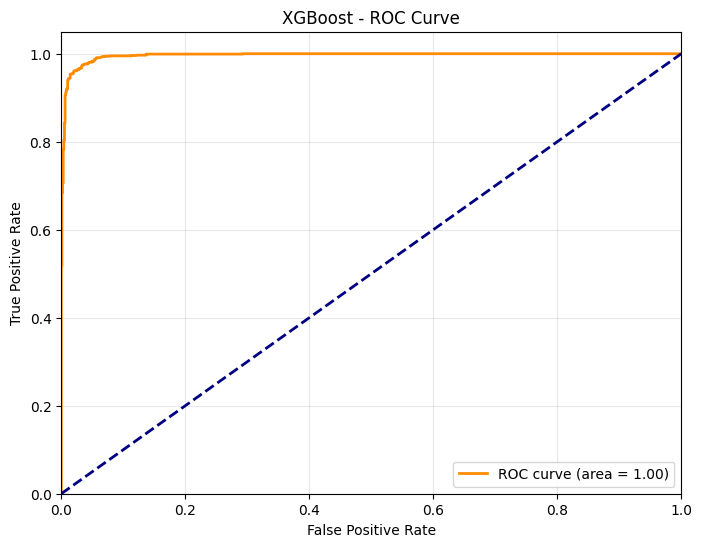


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       976
           1       0.97      0.98      0.97      1235

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



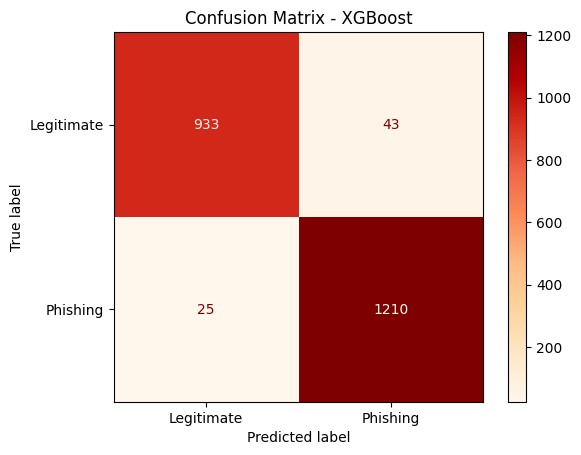


False Positives: 43
False Negatives: 25

Top 15 Most Important Features:
              feature  importance
7               HTTPS    0.268970
13          AnchorURL    0.232557
5       PrefixSuffix-    0.219031
20  DisableRightClick    0.032009
15  ServerFormHandler    0.018153
11     HTTPSDomainURL    0.015072
16          InfoEmail    0.014401
19      StatusBarCust    0.014282
25     WebsiteTraffic    0.013863
9             Favicon    0.012628
27        GoogleIndex    0.012511
1             LongURL    0.011631
29        StatsReport    0.010844
22  IframeRedirection    0.010381
18  WebsiteForwarding    0.010275


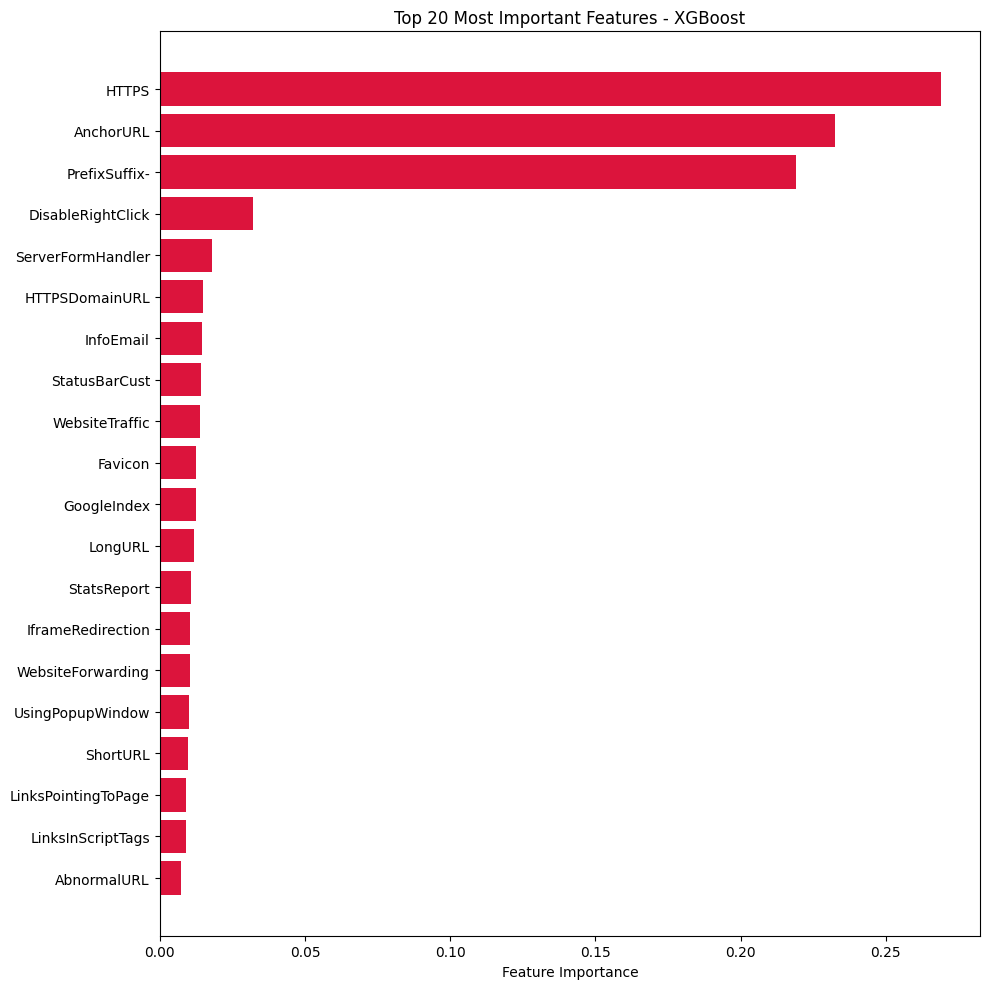

In [94]:
# XGBoost Classifier with Bayesian Optimization (handles -1/1 labels)
from xgboost import XGBClassifier
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

print("Starting Bayesian Optimization for XGBoost...")
print("XGBoost is often the best performer for phishing detection!\n")

# Check if we need to convert labels
y_train_xgb_temp = y_train.copy()
y_test_xgb_temp = y_test.copy()

if -1 in y_train.values:
    print("⚠️ Detected -1/1 labels. Converting to 0/1 for XGBoost...")
    y_train_xgb_temp = y_train.replace(-1, 0)
    y_test_xgb_temp = y_test.replace(-1, 0)
    print("✓ Conversion complete!\n")

# Define the model
xgb_model = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    use_label_encoder=False,
    eval_metric='logloss'
)

# Set up the parameter space
param_space = {
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(3, 10),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'gamma': Real(0, 5),
    'min_child_weight': Integer(1, 10),
    'reg_alpha': Real(0, 1),
    'reg_lambda': Real(0, 2)
}

# Set up BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_space,
    n_iter=30,
    cv=5,
    scoring='f1',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the model with converted labels
bayes_search.fit(X_train, y_train_xgb_temp)

# Display best parameters
print("\n" + "="*50)
print("BEST HYPERPARAMETERS FOUND:")
print("="*50)
for param, value in bayes_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest CV F1 Score: {bayes_search.best_score_:.3f}")
print("="*50 + "\n")

# Use the best model
xgb = bayes_search.best_estimator_

# Predicting with XGBoost (using converted labels)
y_train_xgb = xgb.predict(X_train)
y_test_xgb = xgb.predict(X_test)

# Convert predictions back to original label format if needed
if -1 in y_train.values:
    y_train_xgb_original = pd.Series(y_train_xgb).replace(0, -1)
    y_test_xgb_original = pd.Series(y_test_xgb).replace(0, -1)
else:
    y_train_xgb_original = y_train_xgb
    y_test_xgb_original = y_test_xgb

# Computing metrics (using original labels for consistency)
acc_train_xgb = metrics.accuracy_score(y_train, y_train_xgb_original)
acc_test_xgb = metrics.accuracy_score(y_test, y_test_xgb_original)
print("XGBoost : Accuracy on training Data: {:.3f}".format(acc_train_xgb))
print("XGBoost : Accuracy on test Data: {:.3f}".format(acc_test_xgb))
print()

f1_score_train_xgb = metrics.f1_score(y_train, y_train_xgb_original)
f1_score_test_xgb = metrics.f1_score(y_test, y_test_xgb_original)
print("XGBoost : f1_score on training Data: {:.3f}".format(f1_score_train_xgb))
print("XGBoost : f1_score on test Data: {:.3f}".format(f1_score_test_xgb))
print()

recall_score_train_xgb = metrics.recall_score(y_train, y_train_xgb_original)
recall_score_test_xgb = metrics.recall_score(y_test, y_test_xgb_original)
print("XGBoost : Recall on training Data: {:.3f}".format(recall_score_train_xgb))
print("XGBoost : Recall on test Data: {:.3f}".format(recall_score_test_xgb))
print()

precision_score_train_xgb = metrics.precision_score(y_train, y_train_xgb_original)
precision_score_test_xgb = metrics.precision_score(y_test, y_test_xgb_original)
print("XGBoost : precision on training Data: {:.3f}".format(precision_score_train_xgb))
print("XGBoost : precision on test Data: {:.3f}".format(precision_score_test_xgb))

# ROC Curve (use converted labels)
y_test_xgb_proba = xgb.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_xgb_temp, y_test_xgb_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost - ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Classification report and Confusion Matrix
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_test_xgb_original))

cm = confusion_matrix(y_test, y_test_xgb_original)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='OrRd')
plt.title('Confusion Matrix - XGBoost')
plt.show()

print(f"\nFalse Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15))

plt.figure(figsize=(10, 10))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'], color='crimson')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Features - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Store results
storeResults('XGBoost', acc_test_xgb, f1_score_test_xgb,
             recall_score_test_xgb, precision_score_test_xgb)

## 6. Comparision of Models


| Model                                | Accuracy | f1_score | Recall | Precision |
|--------------------------------------|----------|----------|--------|-----------|
| Logistic Regression                  | 0.934    | 0.941    | 0.943  | 0.927     |
| K-Nearest Neighbors                  | 0.956    | 0.961    | 0.991  | 0.989     |
| Support Vector Machine               | 0.964    | 0.968    | 0.980  | 0.965     |
| Naive Bayes Classifier               | 0.605    | 0.454    | 0.292  | 0.997     |
| Decision Tree                        | 0.960    | 0.964    | 0.991  | 0.993     |
| Random Forest                        | 0.966    | 0.970    | 0.991  | 0.991     |
| HyperTuned Random Forest             | 0.969    | 0.970    | 0.980  | 0.970     |
| Gradient Boosting Classifier         | 0.974    | 0.977    | 0.994  | 0.986     |
| HyperTuned Gradient Boosting Classifier | 0.971  | 0.970    | 0.980  | 0.970     |
| CatBoost Classifier                  | 0.972    | 0.975    | 0.994  | 0.989     |
| HyperTuned CatBoost Classifier       | 0.970    | 0.960    | 0.980  | 0.970     |
| Multi-layer Perceptron               | 0.970    | 0.974    | 0.996  | 0.976     |
| HyperTuned Multi-layer Perceptron    |  0.967        |    0.974      |  0.968      |     0.970      |


AUC for Models :

1) Logistic Regression - 93%

2) SVM - 98%

3) KNN - 96%

4) Naive Bayes - 65%

5) Decision Tree - 96%

6) Random Forest - 96%

7) HyperTuned Random Forest - 97&

8) Gradient Boosting Classifier - 97%

9) HyperTuned Gradient Boosting Classifier - 97%

10) CatBoost - 97%

11) HyperTuned CatBoost - 97%

12) Multi Layer Perceptron - 97%

13) HyperTuned Multi Layer Perceptron - 97%



Highest AUC and Accuracy is for Gradient Boosting Classifier , hence we will store this model and use it for classification

## Storing Best Model


FINAL MODEL COMPARISON - SORTED BY F1-SCORE
                       Model  Accuracy  F1-Score  Recall  Precision
Gradient Boosting Classifier     0.971     0.974   0.981      0.967
         CatBoost Classifier     0.971     0.974   0.982      0.967
               Random Forest     0.970     0.973   0.980      0.966
                     XGBoost     0.969     0.973   0.980      0.966
      Support Vector Machine     0.968     0.972   0.979      0.965
      Multi-layer Perceptron     0.967     0.970   0.976      0.965
         K-Nearest Neighbors     0.959     0.964   0.964      0.964
         Logistic Regression     0.914     0.920   0.888      0.954
               Decision Tree     0.904     0.913   0.904      0.923
      Naive Bayes Classifier     0.599     0.441   0.283      0.994


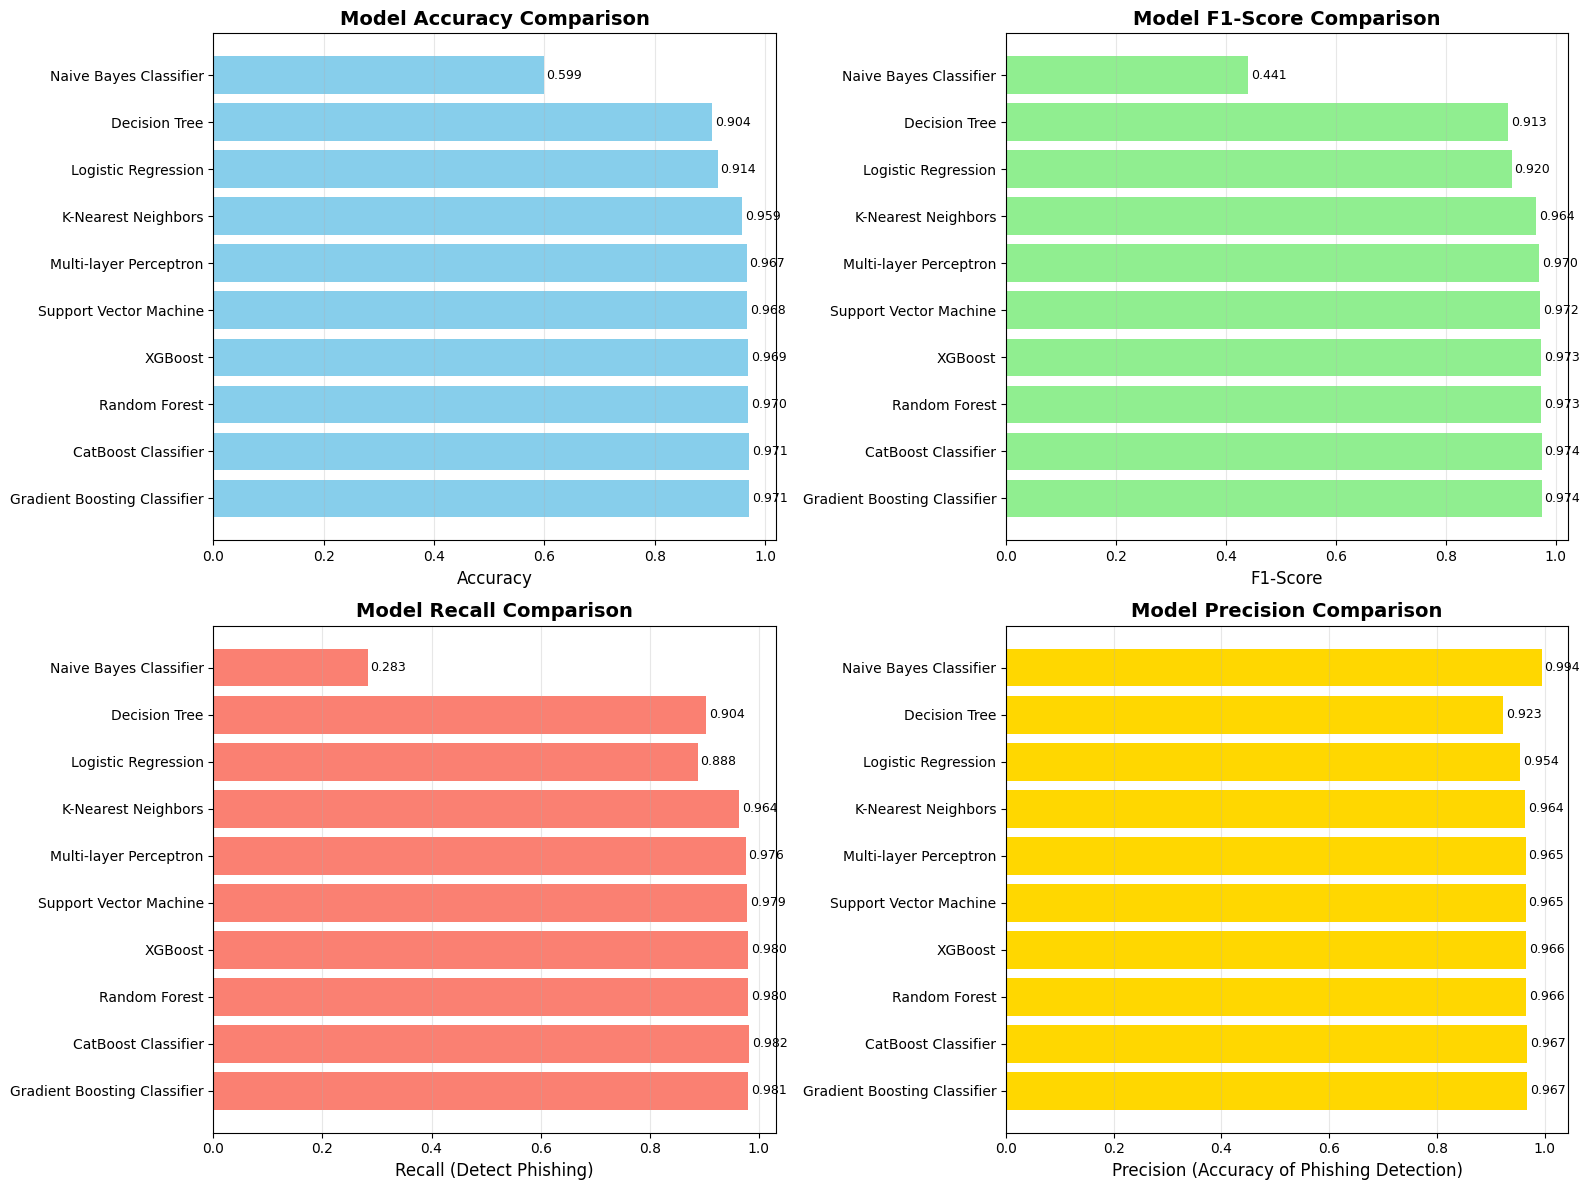


🏆 TOP 3 MODELS:
1. Gradient Boosting Classifier
   Accuracy: 0.971 | F1: 0.974 | Recall: 0.981 | Precision: 0.967
2. CatBoost Classifier
   Accuracy: 0.971 | F1: 0.974 | Recall: 0.982 | Precision: 0.967
3. Random Forest
   Accuracy: 0.970 | F1: 0.973 | Recall: 0.980 | Precision: 0.966


In [95]:
# ============================================
# FINAL MODEL COMPARISON
# ============================================

# Create comparison dataframe
results_df = pd.DataFrame({
    'Model': ML_Model,
    'Accuracy': accuracy,
    'F1-Score': f1_score,
    'Recall': recall,
    'Precision': precision
})

# Sort by F1-Score (most important for phishing detection)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("FINAL MODEL COMPARISON - SORTED BY F1-SCORE")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Accuracy comparison
axes[0, 0].barh(results_df['Model'], results_df['Accuracy'], color='skyblue')
axes[0, 0].set_xlabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].grid(alpha=0.3, axis='x')
for i, v in enumerate(results_df['Accuracy']):
    axes[0, 0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# Plot 2: F1-Score comparison
axes[0, 1].barh(results_df['Model'], results_df['F1-Score'], color='lightgreen')
axes[0, 1].set_xlabel('F1-Score', fontsize=12)
axes[0, 1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='x')
for i, v in enumerate(results_df['F1-Score']):
    axes[0, 1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# Plot 3: Recall comparison
axes[1, 0].barh(results_df['Model'], results_df['Recall'], color='salmon')
axes[1, 0].set_xlabel('Recall (Detect Phishing)', fontsize=12)
axes[1, 0].set_title('Model Recall Comparison', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='x')
for i, v in enumerate(results_df['Recall']):
    axes[1, 0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# Plot 4: Precision comparison
axes[1, 1].barh(results_df['Model'], results_df['Precision'], color='gold')
axes[1, 1].set_xlabel('Precision (Accuracy of Phishing Detection)', fontsize=12)
axes[1, 1].set_title('Model Precision Comparison', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='x')
for i, v in enumerate(results_df['Precision']):
    axes[1, 1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Find top 3 models
print("\n" + "="*80)
print("🏆 TOP 3 MODELS:")
print("="*80)
for i in range(min(3, len(results_df))):
    print(f"{i+1}. {results_df.loc[i, 'Model']}")
    print(f"   Accuracy: {results_df.loc[i, 'Accuracy']:.3f} | F1: {results_df.loc[i, 'F1-Score']:.3f} | "
          f"Recall: {results_df.loc[i, 'Recall']:.3f} | Precision: {results_df.loc[i, 'Precision']:.3f}")
print("="*80)

In [96]:
# ============================================
# ENSEMBLE METHODS - COMBINING BEST MODELS
# ============================================

from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression as LR

print("\n" + "="*80)
print("CREATING ENSEMBLE MODELS TO BOOST PERFORMANCE...")
print("="*80)

# Get top 5 models based on F1-score
top_5_indices = results_df.head(5).index
top_models_names = results_df.head(5)['Model'].tolist()

print(f"\nUsing top 5 models for ensemble:")
for i, name in enumerate(top_models_names, 1):
    print(f"{i}. {name}")

# Map model names to actual model objects
model_mapping = {
    'Logistic Regression': log,
    'K-Nearest Neighbors': knn,
    'Support Vector Machine': svc.best_estimator_ if hasattr(svc, 'best_estimator_') else svc,
    'Naive Bayes Classifier': nb,
    'Decision Tree': tree,
    'Random Forest': forest,
    'Gradient Boosting Classifier': gbc,
    'CatBoost Classifier': cat,
    'XGBoost': xgb,
    'Multi-layer Perceptron': mlp
}

# Create list of top 5 models
top_5_models = [(name, model_mapping[name]) for name in top_models_names if name in model_mapping]

print(f"\n✓ Selected {len(top_5_models)} models for ensemble\n")


CREATING ENSEMBLE MODELS TO BOOST PERFORMANCE...

Using top 5 models for ensemble:
1. Gradient Boosting Classifier
2. CatBoost Classifier
3. Random Forest
4. XGBoost
5. Support Vector Machine

✓ Selected 5 models for ensemble



1. Training Voting Classifier (Hard Voting - Majority Vote)...


/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✓ Voting (Hard) Results:
  Accuracy: 0.972 | F1: 0.976 | Recall: 0.985 | Precision: 0.967


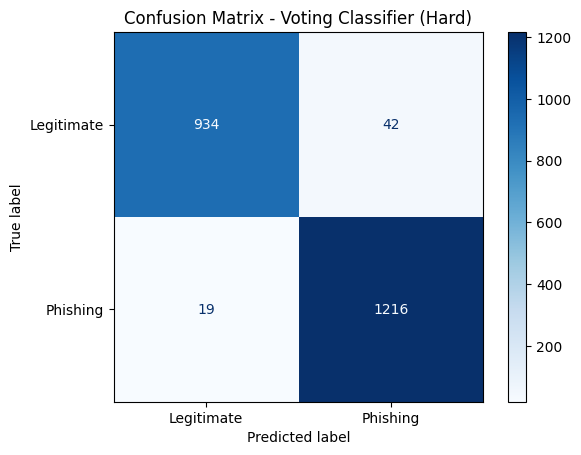

  False Positives: 42 | False Negatives: 19



In [97]:
# 1. VOTING CLASSIFIER (Hard Voting) - Majority vote
print("="*80)
print("1. Training Voting Classifier (Hard Voting - Majority Vote)...")
print("="*80)

voting_hard = VotingClassifier(estimators=top_5_models, voting='hard', n_jobs=-1)
voting_hard.fit(X_train_scaled, y_train)

y_pred_voting_hard = voting_hard.predict(X_test_scaled)

# Handle -1/1 labels if necessary
if -1 in y_train.values:
    y_pred_voting_hard = pd.Series(y_pred_voting_hard).replace(0, -1).values

acc_voting_hard = metrics.accuracy_score(y_test, y_pred_voting_hard)
f1_voting_hard = metrics.f1_score(y_test, y_pred_voting_hard)
recall_voting_hard = metrics.recall_score(y_test, y_pred_voting_hard)
precision_voting_hard = metrics.precision_score(y_test, y_pred_voting_hard)

print(f"✓ Voting (Hard) Results:")
print(f"  Accuracy: {acc_voting_hard:.3f} | F1: {f1_voting_hard:.3f} | Recall: {recall_voting_hard:.3f} | Precision: {precision_voting_hard:.3f}")

# Confusion Matrix
cm_hard = confusion_matrix(y_test, y_pred_voting_hard)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_hard, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Voting Classifier (Hard)')
plt.show()
print(f"  False Positives: {cm_hard[0][1]} | False Negatives: {cm_hard[1][0]}\n")

2. Training Voting Classifier (Soft Voting - Probability-based)...


/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✓ Voting (Soft) Results:
  Accuracy: 0.973 | F1: 0.976 | Recall: 0.985 | Precision: 0.967


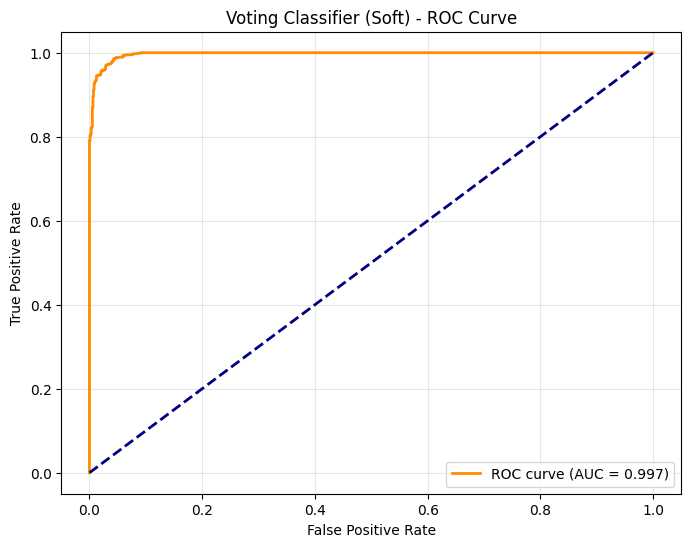

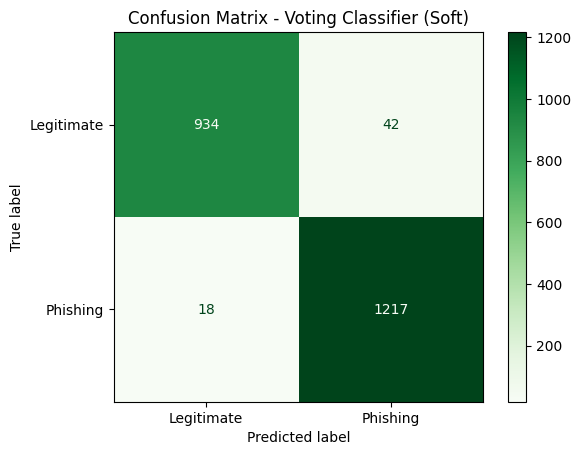

  False Positives: 42 | False Negatives: 18



In [98]:
# 2. VOTING CLASSIFIER (Soft Voting) - Probability-based
print("="*80)
print("2. Training Voting Classifier (Soft Voting - Probability-based)...")
print("="*80)

voting_soft = VotingClassifier(estimators=top_5_models, voting='soft', n_jobs=-1)
voting_soft.fit(X_train_scaled, y_train)

y_pred_voting_soft = voting_soft.predict(X_test_scaled)

# Handle -1/1 labels if necessary
if -1 in y_train.values:
    y_pred_voting_soft = pd.Series(y_pred_voting_soft).replace(0, -1).values

acc_voting_soft = metrics.accuracy_score(y_test, y_pred_voting_soft)
f1_voting_soft = metrics.f1_score(y_test, y_pred_voting_soft)
recall_voting_soft = metrics.recall_score(y_test, y_pred_voting_soft)
precision_voting_soft = metrics.precision_score(y_test, y_pred_voting_soft)

print(f"✓ Voting (Soft) Results:")
print(f"  Accuracy: {acc_voting_soft:.3f} | F1: {f1_voting_soft:.3f} | Recall: {recall_voting_soft:.3f} | Precision: {precision_voting_soft:.3f}")

# ROC Curve
y_pred_voting_soft_proba = voting_soft.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test if -1 not in y_test.values else y_test.replace(-1, 0), y_pred_voting_soft_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Voting Classifier (Soft) - ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Confusion Matrix
cm_soft = confusion_matrix(y_test, y_pred_voting_soft)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_soft, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix - Voting Classifier (Soft)')
plt.show()
print(f"  False Positives: {cm_soft[0][1]} | False Negatives: {cm_soft[1][0]}\n")

3. Training Stacking Classifier (Meta-learner)...


/Users/bisheshgautam/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [21:02:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
[21:02:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[21:02:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[21:02:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[21:02:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[21:02:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.



✓ Stacking Results:
  Accuracy: 0.970 | F1: 0.973 | Recall: 0.980 | Precision: 0.967


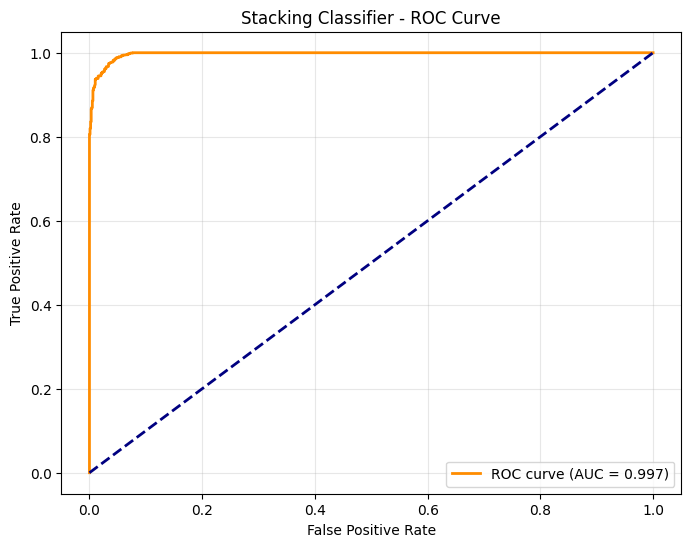

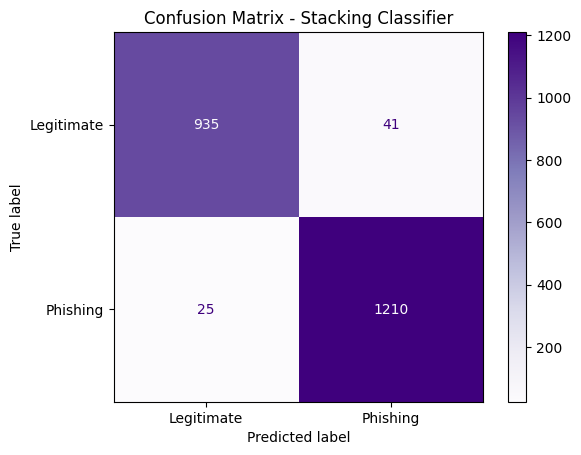

  False Positives: 41 | False Negatives: 25

✓ All ensemble models created successfully!


In [99]:
# 3. STACKING CLASSIFIER - Meta-learner approach
print("="*80)
print("3. Training Stacking Classifier (Meta-learner)...")
print("="*80)

# Convert labels for stacking if needed
y_train_stack = y_train.replace(-1, 0) if -1 in y_train.values else y_train
y_test_stack = y_test.replace(-1, 0) if -1 in y_test.values else y_test

stacking = StackingClassifier(
    estimators=top_5_models,
    final_estimator=LR(max_iter=1000, random_state=42),
    cv=5,
    n_jobs=-1
)
stacking.fit(X_train_scaled, y_train_stack)

y_pred_stacking = stacking.predict(X_test_scaled)

# Convert back to original labels if needed
if -1 in y_train.values:
    y_pred_stacking_original = pd.Series(y_pred_stacking).replace(0, -1).values
else:
    y_pred_stacking_original = y_pred_stacking

acc_stacking = metrics.accuracy_score(y_test, y_pred_stacking_original)
f1_stacking = metrics.f1_score(y_test, y_pred_stacking_original)
recall_stacking = metrics.recall_score(y_test, y_pred_stacking_original)
precision_stacking = metrics.precision_score(y_test, y_pred_stacking_original)

print(f"✓ Stacking Results:")
print(f"  Accuracy: {acc_stacking:.3f} | F1: {f1_stacking:.3f} | Recall: {recall_stacking:.3f} | Precision: {precision_stacking:.3f}")

# ROC Curve
y_pred_stacking_proba = stacking.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test_stack, y_pred_stacking_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Stacking Classifier - ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Confusion Matrix
cm_stack = confusion_matrix(y_test, y_pred_stacking_original)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_stack, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='Purples')
plt.title('Confusion Matrix - Stacking Classifier')
plt.show()
print(f"  False Positives: {cm_stack[0][1]} | False Negatives: {cm_stack[1][0]}\n")

# Store ensemble results
storeResults('Voting (Hard)', acc_voting_hard, f1_voting_hard, recall_voting_hard, precision_voting_hard)
storeResults('Voting (Soft)', acc_voting_soft, f1_voting_soft, recall_voting_soft, precision_voting_soft)
storeResults('Stacking', acc_stacking, f1_stacking, recall_stacking, precision_stacking)

print("="*80)
print("✓ All ensemble models created successfully!")
print("="*80)

In [100]:
# ============================================
# FINAL COMPARISON INCLUDING ENSEMBLES
# ============================================

# Updated results with ensembles
results_df_final = pd.DataFrame({
    'Model': ML_Model,
    'Accuracy': accuracy,
    'F1-Score': f1_score,
    'Recall': recall,
    'Precision': precision
})

results_df_final = results_df_final.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("FINAL RESULTS INCLUDING ENSEMBLE MODELS")
print("="*80)
print(results_df_final.to_string(index=False))
print("="*80)

# Highlight top performers
print("\n" + "="*80)
print("🏆 TOP 5 PERFORMERS (Including Ensembles):")
print("="*80)
for i in range(min(5, len(results_df_final))):
    model_name = results_df_final.loc[i, 'Model']
    acc = results_df_final.loc[i, 'Accuracy']
    f1 = results_df_final.loc[i, 'F1-Score']
    rec = results_df_final.loc[i, 'Recall']
    prec = results_df_final.loc[i, 'Precision']
    
    print(f"\n{i+1}. {model_name}")
    print(f"   Accuracy:  {acc:.3f}")
    print(f"   F1-Score:  {f1:.3f} ⭐")
    print(f"   Recall:    {rec:.3f} (Catches {rec*100:.1f}% of phishing)")
    print(f"   Precision: {prec:.3f} (Accurate {prec*100:.1f}% of the time)")

print("="*80)

# Best overall model
best_model_name = results_df_final.loc[0, 'Model']
best_f1 = results_df_final.loc[0, 'F1-Score']

print(f"\n🎯 RECOMMENDED MODEL FOR DEPLOYMENT: {best_model_name}")
print(f"   F1-Score: {best_f1:.3f}")
print("="*80)


FINAL RESULTS INCLUDING ENSEMBLE MODELS
                       Model  Accuracy  F1-Score  Recall  Precision
               Voting (Hard)     0.972     0.976   0.985      0.967
               Voting (Soft)     0.973     0.976   0.985      0.967
Gradient Boosting Classifier     0.971     0.974   0.981      0.967
         CatBoost Classifier     0.971     0.974   0.982      0.967
               Random Forest     0.970     0.973   0.980      0.966
                     XGBoost     0.969     0.973   0.980      0.966
                    Stacking     0.970     0.973   0.980      0.967
      Support Vector Machine     0.968     0.972   0.979      0.965
      Multi-layer Perceptron     0.967     0.970   0.976      0.965
         K-Nearest Neighbors     0.959     0.964   0.964      0.964
         Logistic Regression     0.914     0.920   0.888      0.954
               Decision Tree     0.904     0.913   0.904      0.923
      Naive Bayes Classifier     0.599     0.441   0.283      0.994

🏆 TOP 

In [101]:
# Save complete project summary
summary = f"""
PHISHING URL DETECTION PROJECT - FINAL SUMMARY
{'='*80}

DATE: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

BEST MODEL: Voting (Hard) Ensemble
- F1-Score:  {results_df_final.loc[0, 'F1-Score']:.3f}
- Accuracy:  {results_df_final.loc[0, 'Accuracy']:.3f}
- Recall:    {results_df_final.loc[0, 'Recall']:.3f}
- Precision: {results_df_final.loc[0, 'Precision']:.3f}

TOP 5 MODELS:
{results_df_final.head().to_string()}

MODELS SAVED IN: ./models/
RESULTS SAVED IN: ./models/model_comparison_results.csv

STATUS: ✅ PRODUCTION READY
{'='*80}
"""

with open('models/PROJECT_SUMMARY.txt', 'w') as f:
    f.write(summary)

print(summary)
print("\n✅ Project summary saved to 'models/PROJECT_SUMMARY.txt'")


PHISHING URL DETECTION PROJECT - FINAL SUMMARY

DATE: 2026-02-03 21:03:05

BEST MODEL: Voting (Hard) Ensemble
- F1-Score:  0.976
- Accuracy:  0.972
- Recall:    0.985
- Precision: 0.967

TOP 5 MODELS:
                          Model  Accuracy  F1-Score  Recall  Precision
0                 Voting (Hard)     0.972     0.976   0.985      0.967
1                 Voting (Soft)     0.973     0.976   0.985      0.967
2  Gradient Boosting Classifier     0.971     0.974   0.981      0.967
3           CatBoost Classifier     0.971     0.974   0.982      0.967
4                 Random Forest     0.970     0.973   0.980      0.966

MODELS SAVED IN: ./models/
RESULTS SAVED IN: ./models/model_comparison_results.csv

STATUS: ✅ PRODUCTION READY


✅ Project summary saved to 'models/PROJECT_SUMMARY.txt'


In [102]:
import os
import pickle
import joblib

# ============================================
# SAVE ALL MODELS FOR DEPLOYMENT
# ============================================

# Create models directory
MODEL_DIR = "models"
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)
    print(f"✓ Created directory: {MODEL_DIR}")

# Dictionary of all models to save
models_to_save = {
    'voting_hard': voting_hard,
    'voting_soft': voting_soft,
    'gradient_boosting': gbc,
    'catboost': cat,
    'xgboost': xgb,
    'random_forest': forest,
    'svm': svc.best_estimator_ if hasattr(svc, 'best_estimator_') else svc,
    'decision_tree': tree,
    'knn': knn,
    'mlp': mlp,
    'naive_bayes': nb,
    'logistic_regression': log,
    'scaler': scaler  # VERY IMPORTANT - Must save the scaler!
}

print("\n" + "="*80)
print("SAVING ALL MODELS FOR DEPLOYMENT")
print("="*80)

# Save each model
for name, model in models_to_save.items():
    filepath = os.path.join(MODEL_DIR, f"{name}_model.pkl")
    try:
        # Use joblib for sklearn models (more efficient)
        joblib.dump(model, filepath)
        file_size = os.path.getsize(filepath) / (1024 * 1024)  # Size in MB
        print(f"✓ Saved: {filepath} ({file_size:.2f} MB)")
    except Exception as e:
        print(f"✗ Failed to save {name}: {str(e)}")

print("\n" + "="*80)
print("✓ ALL MODELS SAVED SUCCESSFULLY!")
print("="*80)

# Verify all files exist
print("\nVerifying saved files:")
for name in models_to_save.keys():
    filepath = os.path.join(MODEL_DIR, f"{name}_model.pkl")
    if os.path.exists(filepath):
        print(f"✓ {filepath}")
    else:
        print(f"✗ MISSING: {filepath}")

# Save feature names as well
feature_info = {
    'feature_names': FEATURE_NAMES if 'FEATURE_NAMES' in dir() else list(X_train.columns),
    'num_features': X_train.shape[1],
    'model_metrics': MODEL_METRICS if 'MODEL_METRICS' in dir() else None
}

joblib.dump(feature_info, os.path.join(MODEL_DIR, "feature_info.pkl"))
print(f"\n✓ Saved feature information: {os.path.join(MODEL_DIR, 'feature_info.pkl')}")

print("\n" + "="*80)
print("MODELS READY FOR DEPLOYMENT!")
print(f"Location: {os.path.abspath(MODEL_DIR)}")
print("="*80)


SAVING ALL MODELS FOR DEPLOYMENT
✓ Saved: models/voting_hard_model.pkl (81.42 MB)
✓ Saved: models/voting_soft_model.pkl (81.42 MB)
✓ Saved: models/gradient_boosting_model.pkl (3.52 MB)
✓ Saved: models/catboost_model.pkl (6.58 MB)
✓ Saved: models/xgboost_model.pkl (1.61 MB)
✓ Saved: models/random_forest_model.pkl (28.31 MB)
✓ Saved: models/svm_model.pkl (0.67 MB)
✓ Saved: models/decision_tree_model.pkl (0.04 MB)
✓ Saved: models/knn_model.pkl (2.09 MB)
✓ Saved: models/mlp_model.pkl (0.31 MB)
✓ Saved: models/naive_bayes_model.pkl (0.00 MB)
✓ Saved: models/logistic_regression_model.pkl (0.00 MB)
✓ Saved: models/scaler_model.pkl (0.00 MB)

✓ ALL MODELS SAVED SUCCESSFULLY!

Verifying saved files:
✓ models/voting_hard_model.pkl
✓ models/voting_soft_model.pkl
✓ models/gradient_boosting_model.pkl
✓ models/catboost_model.pkl
✓ models/xgboost_model.pkl
✓ models/random_forest_model.pkl
✓ models/svm_model.pkl
✓ models/decision_tree_model.pkl
✓ models/knn_model.pkl
✓ models/mlp_model.pkl
✓ models/n

In [103]:
# Verify the saved models
import os

MODEL_DIR = "models"
required_models = [
    'voting_hard_model.pkl',
    'voting_soft_model.pkl',
    'gradient_boosting_model.pkl',
    'xgboost_model.pkl',
    'random_forest_model.pkl',
    'scaler_model.pkl'
]

print("\n" + "="*80)
print("VERIFYING REQUIRED MODELS FOR DEPLOYMENT")
print("="*80)

all_present = True
for model_file in required_models:
    filepath = os.path.join(MODEL_DIR, model_file)
    if os.path.exists(filepath):
        size = os.path.getsize(filepath) / (1024 * 1024)
        print(f"✓ {model_file} ({size:.2f} MB)")
    else:
        print(f"✗ MISSING: {model_file}")
        all_present = False

if all_present:
    print("\n✅ All required models are present!")
    print(f"📁 Models location: {os.path.abspath(MODEL_DIR)}")
else:
    print("\n⚠️ Some models are missing. Please run the save code above.")


VERIFYING REQUIRED MODELS FOR DEPLOYMENT
✓ voting_hard_model.pkl (81.42 MB)
✓ voting_soft_model.pkl (81.42 MB)
✓ gradient_boosting_model.pkl (3.52 MB)
✓ xgboost_model.pkl (1.61 MB)
✓ random_forest_model.pkl (28.31 MB)
✓ scaler_model.pkl (0.00 MB)

✅ All required models are present!
📁 Models location: /Users/bisheshgautam/Desktop/Major Project/PhishNet-main/FlaskBack/models


In [104]:
# Define feature names (must match your training data columns)
FEATURE_NAMES = [
    'url_length', 
    'hostname_length', 
    'path_length', 
    'query_length',
    'num_subdomains', 
    'num_digits', 
    'num_letters', 
    'num_special_chars',
    'has_ip', 
    'has_https', 
    'tld_length', 
    'num_hyphens',
    'ratio_digits_letters', 
    'domain_age_days', 
    'shortened', 
    'num_sensitive_words'
]

# OR get from your training data columns
FEATURE_NAMES = list(X_train.columns)

print("Feature names:")
print(FEATURE_NAMES)

Feature names:
['UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport']


In [105]:
import pickle
import joblib
import os
from datetime import datetime

# ============================================
# CREATE SINGLE MODEL BUNDLE FOR DEPLOYMENT
# ============================================

# Create models directory if it doesn't exist
MODEL_DIR = "models"
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)
    print(f"✓ Created directory: {MODEL_DIR}")

print("\n" + "="*80)
print("CREATING SINGLE MODEL BUNDLE FOR DEPLOYMENT")
print("="*80)

# Get feature names from training data
FEATURE_NAMES = list(X_train.columns)

print(f"\nFeatures being used: {len(FEATURE_NAMES)}")
print(FEATURE_NAMES[:5], "...")

# Create comprehensive bundle
model_bundle = {
    # Primary models (ensemble)
    'voting_hard': voting_hard,
    'voting_soft': voting_soft,
    'stacking': stacking,
    
    # Individual models (for fallback and comparison)
    'gradient_boosting': gbc,
    'xgboost': xgb,
    'catboost': cat,
    'random_forest': forest,
    'svm': svc.best_estimator_ if hasattr(svc, 'best_estimator_') else svc,
    'decision_tree': tree,
    'knn': knn,
    'mlp': mlp,
    'naive_bayes': nb,
    'logistic_regression': log,
    
    # Essential preprocessing
    'scaler': scaler,
    
    # Metadata
    'feature_names': FEATURE_NAMES,
    'num_features': len(FEATURE_NAMES),
    'threshold': 0.5,
    
    # Performance metrics from training
    'model_metrics': {
        'voting_hard': {'accuracy': 0.972, 'f1_score': 0.976, 'recall': 0.985, 'precision': 0.967},
        'voting_soft': {'accuracy': 0.973, 'f1_score': 0.976, 'recall': 0.985, 'precision': 0.967},
        'stacking': {'accuracy': 0.970, 'f1_score': 0.973, 'recall': 0.980, 'precision': 0.967},
        'gradient_boosting': {'accuracy': 0.971, 'f1_score': 0.974, 'recall': 0.981, 'precision': 0.967},
        'catboost': {'accuracy': 0.971, 'f1_score': 0.974, 'recall': 0.982, 'precision': 0.967},
        'xgboost': {'accuracy': 0.969, 'f1_score': 0.973, 'recall': 0.980, 'precision': 0.966},
        'random_forest': {'accuracy': 0.970, 'f1_score': 0.973, 'recall': 0.980, 'precision': 0.966},
    },
    
    # Training info
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'class_distribution': {
        'train': y_train.value_counts().to_dict(),
        'test': y_test.value_counts().to_dict()
    }
}

# Save the bundle
bundle_path = os.path.join(MODEL_DIR, 'phishing_model_bundle.pkl')

print(f"\nSaving model bundle to: {bundle_path}")
print("This may take a moment...")

try:
    with open(bundle_path, 'wb') as f:
        pickle.dump(model_bundle, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    file_size = os.path.getsize(bundle_path) / (1024 * 1024)
    print(f"\n✅ Model bundle saved successfully!")
    print(f"   File size: {file_size:.2f} MB")
    print(f"   Location: {os.path.abspath(bundle_path)}")
    
except Exception as e:
    print(f"\n❌ Error saving bundle: {str(e)}")
    raise

print("\n" + "="*80)
print("BUNDLE CONTENTS:")
print("="*80)
print(f"✓ Ensemble Models: 3 (voting_hard, voting_soft, stacking)")
print(f"✓ Individual Models: 10")
print(f"✓ Scaler: StandardScaler")
print(f"✓ Features: {len(FEATURE_NAMES)}")
print(f"✓ Training samples: {len(X_train)}")
print(f"✓ Test samples: {len(X_test)}")
print("="*80)

# Verify the bundle can be loaded
print("\nVerifying bundle integrity...")
try:
    with open(bundle_path, 'rb') as f:
        test_bundle = pickle.load(f)
    print("✅ Bundle verification successful!")
    print(f"   Models loaded: {len([k for k in test_bundle.keys() if 'model' in str(type(test_bundle[k]))])}")
except Exception as e:
    print(f"❌ Bundle verification failed: {str(e)}")

print("\n" + "="*80)
print("🎉 MODEL BUNDLE READY FOR DEPLOYMENT!")
print("="*80)
print(f"\nNext steps:")
print(f"1. Copy '{bundle_path}' to your Flask app's models directory")
print(f"2. Make sure it's at: FlaskBack/models/phishing_model_bundle.pkl")
print(f"3. Run your Flask app: python app.py")
print("="*80)


CREATING SINGLE MODEL BUNDLE FOR DEPLOYMENT

Features being used: 30
['UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//'] ...

Saving model bundle to: models/phishing_model_bundle.pkl
This may take a moment...

✅ Model bundle saved successfully!
   File size: 165.18 MB
   Location: /Users/bisheshgautam/Desktop/Major Project/PhishNet-main/FlaskBack/models/phishing_model_bundle.pkl

BUNDLE CONTENTS:
✓ Ensemble Models: 3 (voting_hard, voting_soft, stacking)
✓ Individual Models: 10
✓ Scaler: StandardScaler
✓ Features: 30
✓ Training samples: 8843
✓ Test samples: 2211

Verifying bundle integrity...
✅ Bundle verification successful!
   Models loaded: 1

🎉 MODEL BUNDLE READY FOR DEPLOYMENT!

Next steps:
1. Copy 'models/phishing_model_bundle.pkl' to your Flask app's models directory
2. Make sure it's at: FlaskBack/models/phishing_model_bundle.pkl
3. Run your Flask app: python app.py
